In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm


**Instrucciones:**

Dado que el proceso de análisis es similar para los datos de temperatura, humedad y precipitaciones, vamos a utilizar un enfoque estandarizado. Primero, se analiza la variable de precipitaciones mensuales. Para ello, se desarrollan funciones específicas que permiten generar gráficos de manera eficiente. Estas funciones, una vez definidas, se aplicarán también a las otras dos variables (temperatura y humedad) para evitar redundancias y mantener consistencia en el análisis.

El proceso de análisis incluye los siguientes pasos:

1. **Creación de Gráficos Iniciales:** Primero, se generan gráficos que ilustran la serie temporal de precipitaciones mensuales. Estos gráficos serán similares a los presentados en la guía del documento DOCS, denominada "Análisis gráfico".

2. **Descomposición de la Serie Temporal:** Se procede a descomponer la serie temporal en sus componentes de estacionalidad y tendencia. Para ello, se crean gráficos adicionales que incluyen la función de autocorrelación (ACF) y la función de autocorrelación parcial (PACF).

3. **Aplicación del Modelo SARIMAX:** Se utiliza el modelo SARIMA (Seasonal AutoRegressive Integrated Moving Average), que es adecuado para series temporales con estacionalidad. Este modelo permite hacer predicciones basadas en la estacionalidad y la tendencia observadas en los datos.

4. **Gráficos de Predicciones:** Finalmente, se generan gráficos que muestran las predicciones realizadas por el modelo SARIMA a 1, 2 y 5 años.

Cada una de estas funciones de gráficos permite personalizar varios aspectos, como el título del gráfico, los nombres de los ejes X e Y, y las leyendas. De esta manera, puedes ajustar los nombres y etiquetas según tus preferencias para facilitar la interpretación de los resultados.


# Precipitaciones

In [2]:
df_precip_monthly = pd.read_csv('../../../datos/bases/weather-time-series-forecasting/data/precipitaciones_mensual.csv')
df_precip_monthly

,year,Mes,Valor,month,date
0,1976,ENE,46.4,1,1976-01-01
1,1976,FEB,38.6,2,1976-02-01
2,1976,MAR,25.3,3,1976-03-01
3,1976,ABR,15.8,4,1976-04-01
4,1976,MAY,14.3,5,1976-05-01
...,...,...,...,...,...
527,2020,JUN,34.9,6,2020-06-01
528,2020,JUL,32.3,7,2020-07-01
529,2020,AGO,22.1,8,2020-08-01
530,2020,SEP,18.4,9,2020-09-01


In [3]:
df_precip_monthly['Valor'].max()

155.5

## Realizar gráficos

In [4]:
# Gráfico de líneas con los últimos 4 años presentes en el dataset. --------
def lineplot_series(df, title, xaxis, yaxis):
    # Configura el tamaño de la figura y crea la figura y los ejes
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Crea el gráfico utilizando seaborn
    sns.lineplot(data=df, x='year', y='Valor', ax=ax)
    
    # Etiquetas y título
    ax.set_xlabel(xaxis, fontsize=12)
    ax.set_ylabel(yaxis, fontsize=12)
    ax.set_title(title, fontsize=16)

    
    # Devuelve la figura y los ejes
    return fig, ax


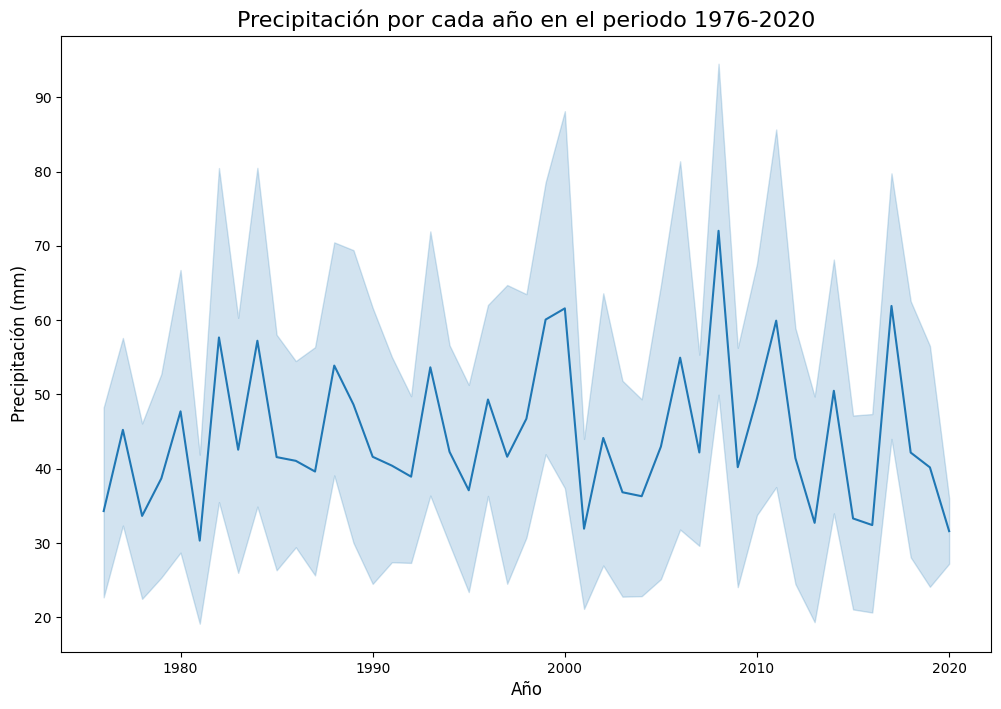

In [5]:
# Realizar gráficos
title = 'Precipitación por cada año en el periodo 1976-2020'
yaxis = 'Precipitación (mm)'
xaxis = 'Año'
legend_title = ''
fig, _ = lineplot_series(df_precip_monthly, title, xaxis, yaxis)

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/precipitaciones/eda1.png'
fig.savefig(save_path) 

In [6]:
# Gráfico de líneas con los últimos 4 años presentes en el dataset. --------
def lineplot_last_4years(df, title, xaxis, yaxis, legend_title):
    
    # Filtrar los datos por los útlimos 4 años 
    ultimo_año = df['year'].max()
    df_last4_year = df.loc[df['year'] >= (ultimo_año - 4)]
    
    # Configura el tamaño de la figura y crea la figura y los ejes
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Crea el gráfico utilizando seaborn
    sns.lineplot(data=df_last4_year, x='Mes', y='Valor', hue='year', palette='tab10', ax=ax)
    
    # Etiquetas y título
    ax.set_xlabel(xaxis, fontsize=12)
    ax.set_ylabel(yaxis, fontsize=12)
    ax.set_title(title, fontsize=16)
    
    # Configura la leyenda
    ax.legend(title=legend_title, bbox_to_anchor=(0.5, -0.08), 
              loc='upper center', ncol=5, 
              frameon=False, fontsize=12)
    
    # Devuelve la figura y los ejes
    return fig, ax


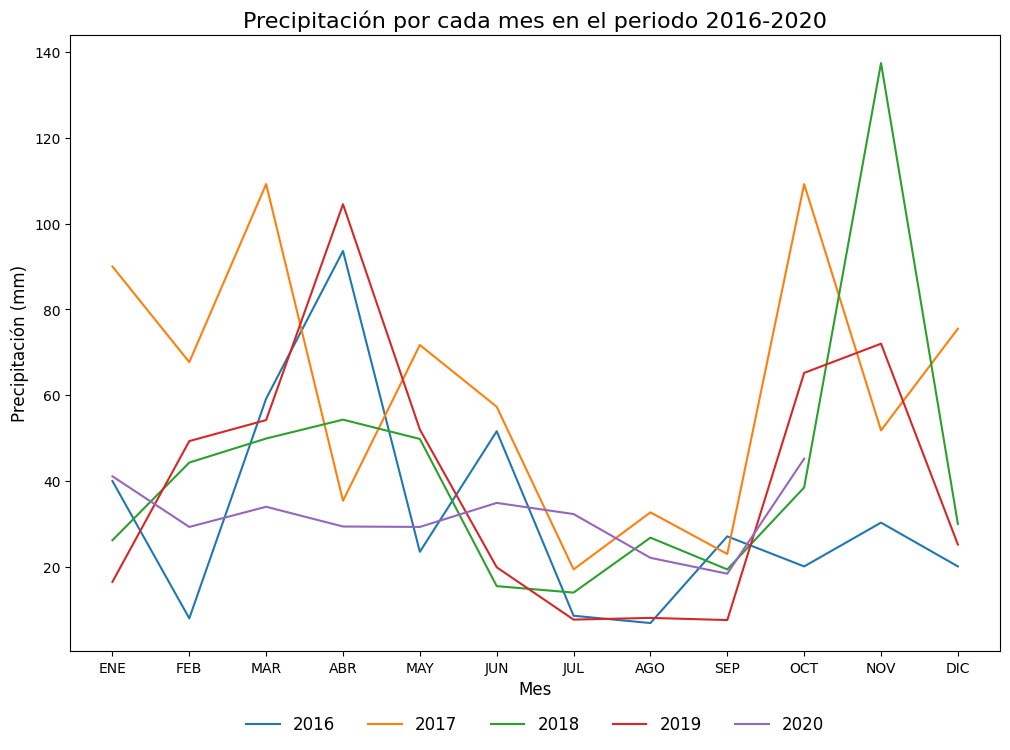

In [7]:
# Realizar gráficos
title = 'Precipitación por cada mes en el periodo 2016-2020'
yaxis = 'Precipitación (mm)'
xaxis = 'Mes'
legend_title = ''
fig, _ = lineplot_last_4years(df_precip_monthly, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/precipitaciones/eda2.png'
fig.savefig(save_path) 

In [8]:
# Gráfico de líneas con las precipitaciones por rangos de años --------
def lineplot_by_ranges(df, title, xaxis, yaxis, legend_title):
    
    df['range'] = np.where((df['year'] >= 1976) & (df['year'] <= 1984), '1976-1984',
               np.where((df['year'] >= 1985) & (df['year'] <= 1993), '1985-1993',
               np.where((df['year'] >= 1994) & (df['year'] <= 2002), '1994-2002',
               np.where((df['year'] >= 2003) & (df['year'] <= 2011), '2003-2011', '2012-2020'))))
      
    # Configura el tamaño de la figura y crea la figura y los ejes
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Crea el gráfico utilizando seaborn
    sns.lineplot(data=df, x='Mes', y='Valor', hue='range', palette='tab10', ax=ax)
    
    # Etiquetas y título
    ax.set_xlabel(xaxis, fontsize=12)
    ax.set_ylabel(yaxis, fontsize=12)
    ax.set_title(title, fontsize=16)
    
    # Configura la leyenda
    ax.legend(title=legend_title, bbox_to_anchor=(0.5, -0.08), 
              loc='upper center', ncol=5, 
              frameon=False, fontsize=12)
    
    # Devuelve la figura y los ejes
    return fig, ax



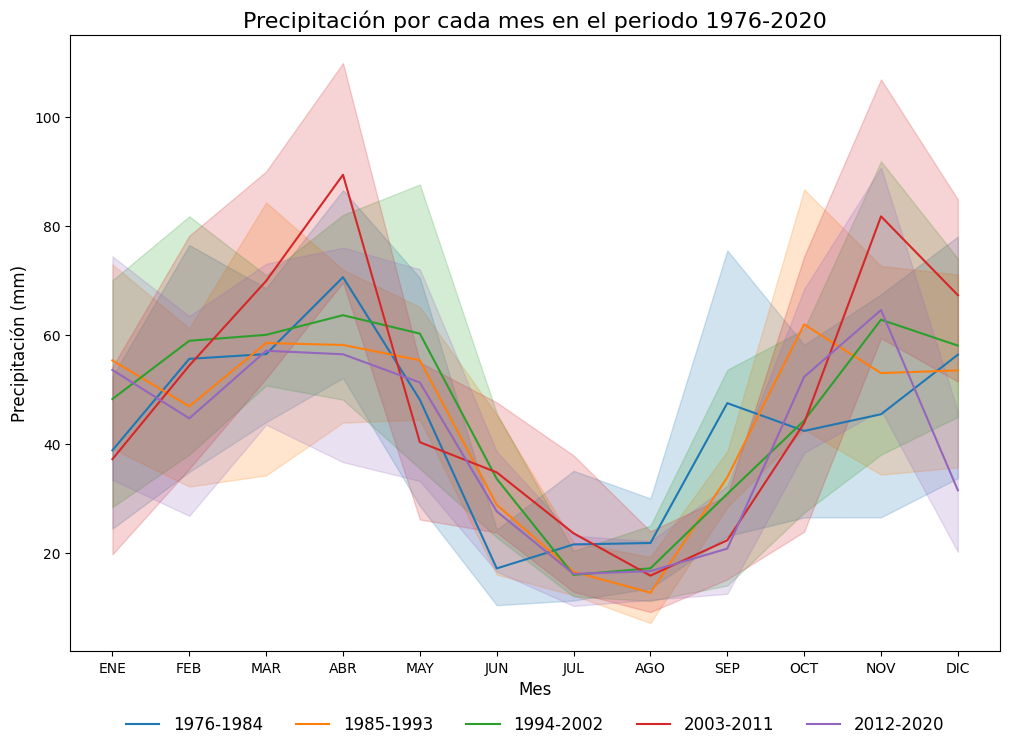

In [9]:
# Realizar gráficos
title = 'Precipitación por cada mes en el periodo 1976-2020'
yaxis = 'Precipitación (mm)'
xaxis = 'Mes'
legend_title = ''
fig, _ = lineplot_by_ranges(df_precip_monthly, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/precipitaciones/eda3.png'
fig.savefig(save_path) 

In [10]:
# Gráfico de líneas con la media de precipitaciones por rangos de años --------
def lineplot_mean_by_ranges(df, title, xaxis, yaxis, legend_title):
    # Define the range categories
    df['range'] = np.where((df['year'] >= 1976) & (df['year'] <= 1984), '1976-1984',
               np.where((df['year'] >= 1985) & (df['year'] <= 1993), '1985-1993',
               np.where((df['year'] >= 1994) & (df['year'] <= 2002), '1994-2002',
               np.where((df['year'] >= 2003) & (df['year'] <= 2011), '2003-2011', '2012-2020'))))

    df = df.groupby(['Mes', 'range'])['Valor'].mean().reset_index()

    # Ensure 'Mes' is a categorical type with proper order
    month_order = ['ENE', 'FEB', 'MAR', 'ABR', 'MAY', 'JUN', 
                   'JUL', 'AGO', 'SEP', 'OCT', 'NOV', 'DIC']
    df['Mes'] = pd.Categorical(df['Mes'], categories=month_order, ordered=True)

    # Configura el tamaño de la figura y crea la figura y los ejes
    fig, ax = plt.subplots(figsize=(12, 8))

    # Crea el gráfico utilizando seaborn
    sns.lineplot(data=df, x='Mes', y='Valor', hue='range', palette='tab10', ax=ax)

    # Etiquetas y título
    ax.set_xlabel(xaxis, fontsize=12)
    ax.set_ylabel(yaxis, fontsize=12)
    ax.set_title(title, fontsize=16)

    # Configura la leyenda
    ax.legend(title=legend_title, bbox_to_anchor=(0.5, -0.08), 
              frameon=False, loc='upper center', ncol=5, fontsize=12)

    # Devuelve la figura y los ejes
    return fig, ax

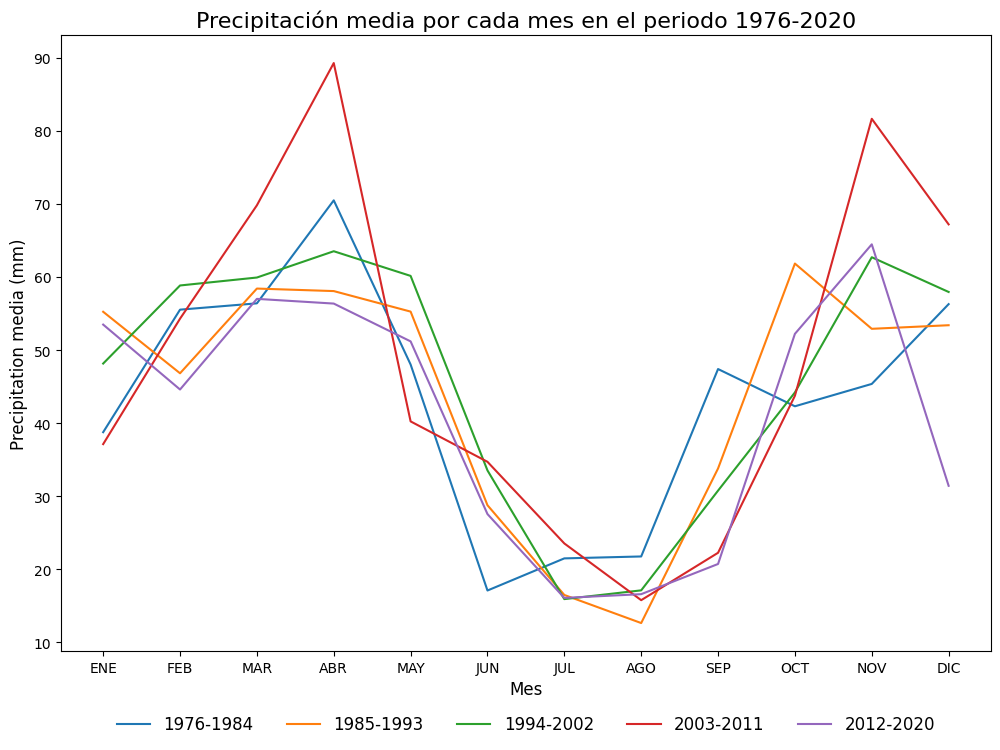

In [11]:
# Realizar gráficos
title = 'Precipitación media por cada mes en el periodo 1976-2020'
yaxis = 'Precipitation media (mm)'
xaxis = 'Mes'
legend_title = ''
fig, _ = lineplot_mean_by_ranges(df_precip_monthly, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/precipitaciones/eda4.png'
fig.savefig(save_path) 

In [12]:
# Gráfico de líneas con la media de precipitaciones --------
def lineplot_mean(df, title, xaxis, yaxis):
    
    # Agrupar por la media
    df = df.groupby('Mes')['Valor'].mean().reset_index()
    
    # Ensure 'Mes' is a categorical type with proper order
    month_order = ['ENE', 'FEB', 'MAR', 'ABR', 'MAY', 'JUN', 
                   'JUL', 'AGO', 'SEP', 'OCT', 'NOV', 'DIC']
    
    df['Mes'] = pd.Categorical(df['Mes'], categories=month_order, ordered=True)
    # Configura el tamaño de la figura y crea la figura y los ejes
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Crea el gráfico utilizando seaborn
    sns.lineplot(data=df, x='Mes', y='Valor', ax=ax)
    
    # Etiquetas y título
    ax.set_xlabel(xaxis, fontsize=12)
    ax.set_ylabel(yaxis, fontsize=12)
    ax.set_title(title, fontsize=16)

    
    # Devuelve la figura y los ejes
    return fig, ax


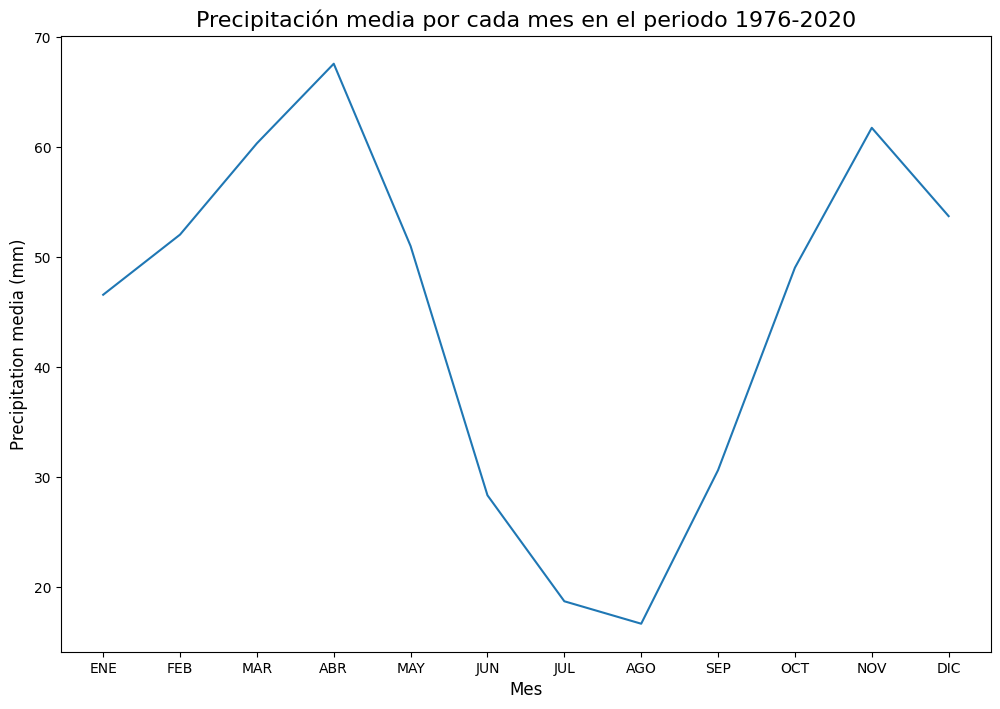

In [13]:
# Utilizar función
title = 'Precipitación media por cada mes en el periodo 1976-2020'
yaxis = 'Precipitation media (mm)'
xaxis = 'Mes'

fig, _ = lineplot_mean(df_precip_monthly, title, xaxis, yaxis)

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/precipitaciones/eda5.png'
fig.savefig(save_path) 

## Analizando la serie temporal

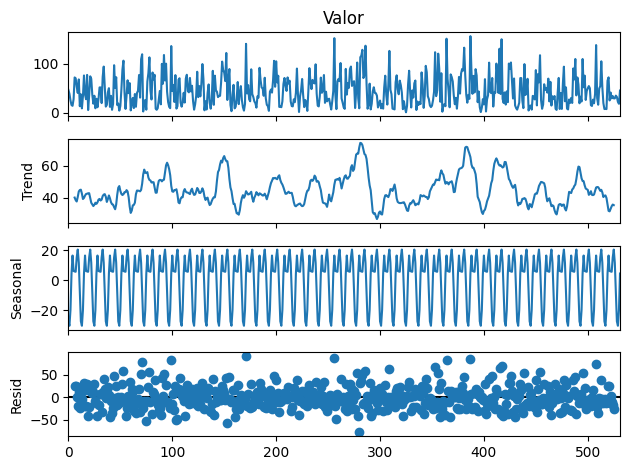

In [14]:
# Se descompone la serie temporal entre tendencia y estacionalidad
result = seasonal_decompose(df_precip_monthly['Valor'], model='additive', period=12)
result.plot()

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/precipitaciones/model1.png'
plt.savefig(save_path) 

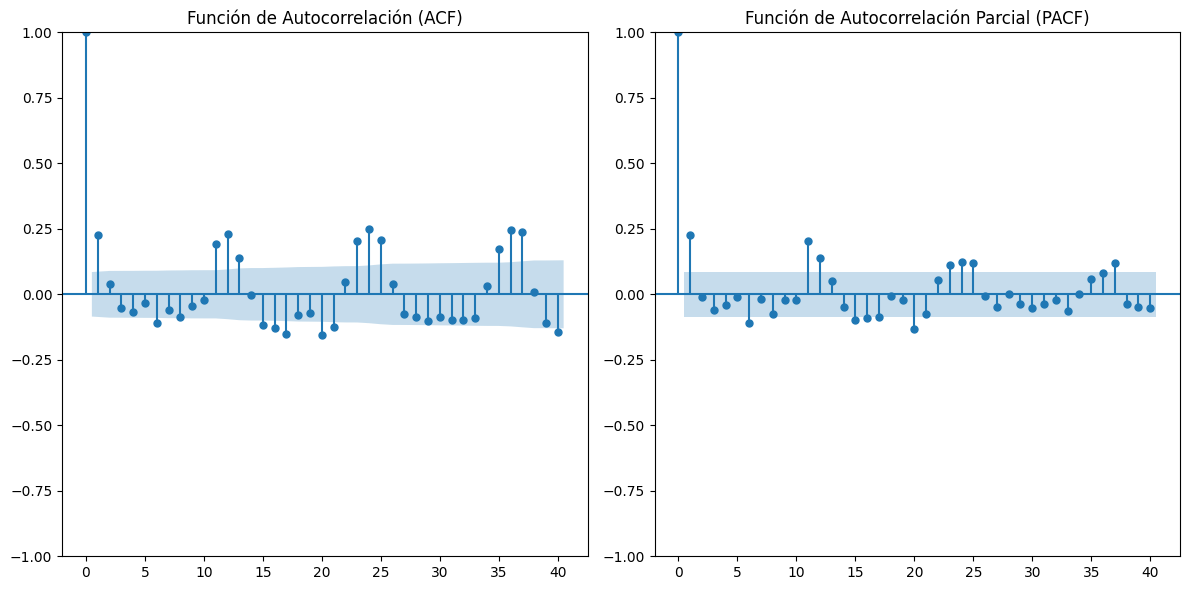

In [15]:
series = df_precip_monthly['Valor']

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plot_acf(series, ax=plt.gca(), lags=40)
plt.title('Función de Autocorrelación (ACF)')

# Gráfico de la PACF
plt.subplot(1, 2, 2)
plot_pacf(series, ax=plt.gca(), lags=40)
plt.title('Función de Autocorrelación Parcial (PACF)')

plt.tight_layout()

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/precipitaciones/model2.png'
plt.savefig(save_path) 

## Creeando modelo SARIMA

In [16]:
# Para crear el modelo y evaluarlo, se divide el conjunto de datos en entrenamiento - prueba
# Luego, se crea el modelo y se realizan predicciones

df_precip_monthly = df_precip_monthly.rename(columns={'Valor': 'value'})

df_precip_monthly.index = pd.to_datetime(df_precip_monthly['date'])
# 1976 only has Jan-Jul on record (data collection started mid-year) -- asfreq('MS') makes that
# gap explicit as 5 missing months instead of silently treating 1977-01 as if it followed
# 1976-07 with no gap, which would distort the seasonal (period=12) structure below.
df_precip_monthly = df_precip_monthly.asfreq('MS')

# Dividir los datos en conjuntos de entrenamiento (80%) y prueba (20%)
train_size = int(len(df_precip_monthly) * 0.8)
train, test = df_precip_monthly[:train_size], df_precip_monthly[train_size:]

# Ajustar el modelo SARIMAX en el conjunto de entrenamiento
model = sm.tsa.statespace.SARIMAX(train['value'], order=(1, 1, 1), seasonal_order=(0, 1, 1, 12))
model_fit = model.fit()

model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              value   No. Observations:                  430
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -2011.611
Date:                            Sat, 12 Sep 2026   AIC                           4031.222
Time:                                    00:47:52   BIC                           4047.354
Sample:                                01-01-1976   HQIC                          4037.600
                                     - 10-01-2011                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0602      0.052      1.155      0.248      -0.042       0.162
ma.L1         -0.9998      0.654     -1.529      0.126      -2.281       0.282
ma.S.L12      -0.9653      0.050    -19.242      0.000      -1.064      -0.867
sigma2       784.6464    516.073      1.520      0.128    -226.839    1796.132
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                89.84
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               1.29   Skew:                             0.94
Prob(H) (two-sided):                  0.13   Kurtosis:                         4.28
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [17]:
import pmdarima as pm
from sklearn.metrics import mean_squared_error

auto_model = pm.auto_arima(train['value'].dropna(), seasonal=True, m=12,
                            stepwise=True, suppress_warnings=True, error_action='ignore')
auto_candidate = sm.tsa.statespace.SARIMAX(train['value'], order=auto_model.order,
                                            seasonal_order=auto_model.seasonal_order).fit(disp=False)

manual_test_pred = model_fit.forecast(steps=len(test))
auto_test_pred = auto_candidate.forecast(steps=len(test))
manual_test_rmse = mean_squared_error(test['value'], manual_test_pred) ** 0.5
auto_test_rmse = mean_squared_error(test['value'], auto_test_pred) ** 0.5

print(f'Manual     (1,1,1)(0,1,1,12)          AIC: {model_fit.aic:.1f}   test RMSE: {manual_test_rmse:.3f}')
print(f'auto_arima {auto_model.order}{auto_model.seasonal_order}   AIC: {auto_candidate.aic:.1f}   test RMSE: {auto_test_rmse:.3f}')

Manual     (1,1,1)(0,1,1,12)          AIC: 4031.2   test RMSE: 27.167
auto_arima (0, 0, 1)(1, 0, 2, 12)   AIC: 4082.0   test RMSE: 26.221


In [18]:
import pmdarima as pm

auto_model = pm.auto_arima(train['value'].dropna(), seasonal=True, m=12,
                            stepwise=True, suppress_warnings=True, error_action='ignore')

print(f'Manual   (1,1,1)(0,1,1,12)         AIC: {model_fit.aic:.1f}')
print(f'auto_arima {auto_model.order}{auto_model.seasonal_order}   AIC: {auto_model.aic():.1f}')

Manual   (1,1,1)(0,1,1,12)         AIC: 4031.2
auto_arima (0, 0, 1)(1, 0, 2, 12)   AIC: 4064.1


**Resultado para Precipitaciones:** auto_arima pierde por AIC pero **gana por error real de test** -- y es el error de test, no el AIC, el que importa para un modelo cuyo trabajo es pronosticar. AIC mide ajuste dentro de la muestra de entrenamiento; aca el orden manual ajusta mejor esa muestra pero generaliza peor al 20% que nunca vio. **Se adopta el orden de auto_arima** para el resto de esta seccion.

In [19]:
# Adoptando el orden de auto_arima para Precipitaciones: generaliza mejor al test (ver arriba).
model_fit = auto_candidate

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

test_predictions = model_fit.forecast(steps=len(test))
rmse = mean_squared_error(test['value'], test_predictions) ** 0.5
mae = mean_absolute_error(test['value'], test_predictions)
mape = (abs((test['value'] - test_predictions) / test['value'])).mean() * 100
results_precip = {'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape}

print(f'Precipitaciones -- error cuantitativo en el 20% de test (mm):')
print(f'  RMSE: {rmse:.3f}')
print(f'  MAE:  {mae:.3f}')
print(f'  MAPE: {mape:.1f}%')

Precipitaciones -- error cuantitativo en el 20% de test (mm):
  RMSE: 26.221
  MAE:  20.636
  MAPE: 88.5%


In [21]:
def lineplot_predictions(test, model, df, title, xaxis, yaxis, legend_title):
    """
    En este gráfico se visualiza la serie completa desde 1976 - 2020.
    Para ello, se realizan las predicciones y se guardan en un dataframe, luego se grafican.
    Con dos colores se separan los datos reales y las predicciones realizadas por el modelo SARIMAX
    """
    # Hacer predicciones en el conjunto de prueba
    predictions = model.forecast(steps=len(test))

    # Crear un DataFrame para almacenar las predicciones y los valores reales
    pred_df = pd.DataFrame({'date': test.index, 'Real': test['value'].values, 'Predicciones': predictions})

    # Crear la figura y los ejes
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Graficar los valores reales vs las predicciones
    ax.plot(df.index, df['value'], label='Datos Reales')
    ax.plot(pred_df['date'], pred_df['Predicciones'], label='Predicciones')
    
    # Etiquetas y título
    ax.set_xlabel(xaxis, fontsize=12)
    ax.set_ylabel(yaxis, fontsize=12)
    ax.set_title(title, fontsize=16)

    ax.legend(title=legend_title, bbox_to_anchor=(0.5, -0.08), 
              loc='upper center', ncol=5, 
              frameon=False, fontsize=12)
    
    # Devolver la figura
    return fig, ax


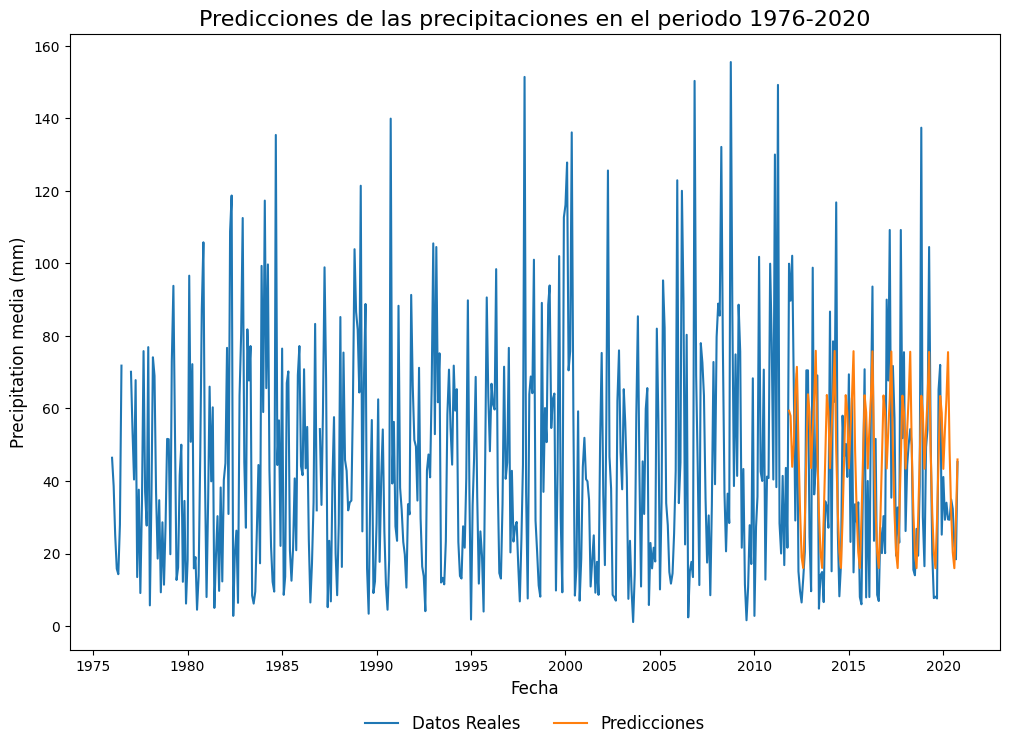

In [22]:
# Usar función

title = 'Predicciones de las precipitaciones en el periodo 1976-2020'
xaxis = 'Fecha'
yaxis = 'Precipitation media (mm)'
legend_title = ''
fig, _ = lineplot_predictions(test, model_fit, df_precip_monthly, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/precipitaciones/model3.png'
plt.savefig(save_path) 

In [23]:
def lineplot_test_predictions(test, model, title, xaxis, yaxis, legend_title):
    """
    Mediante esta funcion se observan los datos reales vs las predcciones realizadas 
    solo para el conjunto de prueba (test)
    """
    # Hacer predicciones en el conjunto de prueba
    predictions = model.forecast(steps=len(test))

    # Crear un DataFrame para almacenar las predicciones y los valores reales
    pred_df = pd.DataFrame({'date': test.index, 'Real': test['value'].values, 'Predicciones': predictions})
    
    # Crear un DataFrame completo para graficar todos los datos, tanto reales como predicciones
    df_all = pd.concat([
        pd.DataFrame({'date': test.index, 'Tipo': 'Real', 'Valor': test['value'].values}),
        pd.DataFrame({'date': test.index, 'Tipo': 'Predicciones', 'Valor': predictions})
    ])

    # Configura el tamaño de la figura y crea la figura y los ejes
    fig, ax = plt.subplots(figsize=(12, 8))

    # Crea el gráfico utilizando seaborn
    sns.lineplot(data=df_all, x='date', y='Valor', hue='Tipo', ax=ax)

    # Etiquetas y título
    ax.set_xlabel(xaxis, fontsize=12)
    ax.set_ylabel(yaxis, fontsize=12)
    ax.set_title(title, fontsize=16)

    # Muestra la leyenda
    # Configura la leyenda
    ax.legend(title=legend_title, bbox_to_anchor=(0.5, -0.08), 
              loc='upper center', ncol=5, 
              frameon=False, fontsize=12)

    # Devuelve la figura y los ejes
    return fig, ax

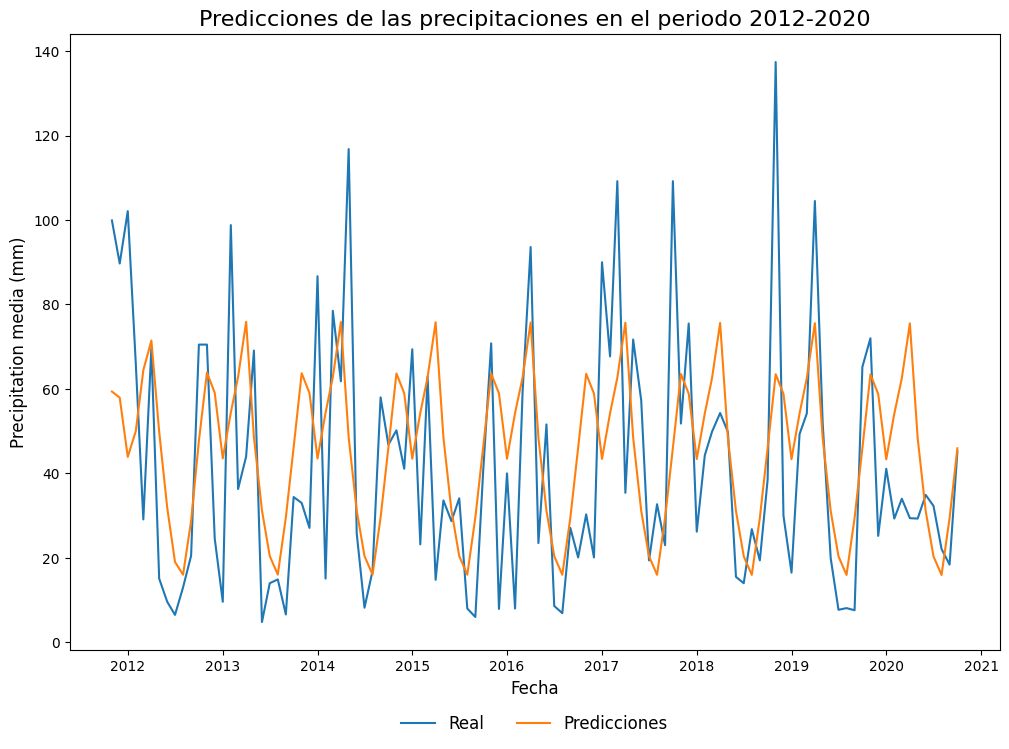

In [24]:
title = 'Predicciones de las precipitaciones en el periodo 2012-2020'
xaxis = 'Fecha'
yaxis = 'Precipitation media (mm)'
legend_title = ''
fig, ax = lineplot_test_predictions(test, model_fit, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/precipitaciones/model4.png'
plt.savefig(save_path) 

In [25]:
def lineplot_predict_n_steps(test, model_fit, steps, title, xaxis, yaxis, legend_title, ax):
    """
    En esta función se grafica el modelo realizado y las predicciones n pasos en el futuro en el eje proporcionado.
    """
    # Hacer predicciones en el conjunto de prueba
    predictions = model_fit.forecast(steps=len(test))
    
    # Hacer predicciones a n pasos adelante
    forecast_n_steps = model_fit.get_forecast(steps=steps)
    forecast_n_steps_index = pd.date_range(start=test.index[-1] + pd.DateOffset(months=1), periods=steps, freq='ME')
    forecast_n_steps_values = forecast_n_steps.predicted_mean
    
    # Crear DataFrames para almacenar las predicciones y los valores reales
    pred_df = pd.DataFrame({'date': test.index, 'Real': test['value'].values, 'Predicciones': predictions})
    forecast_df = pd.DataFrame({'date': forecast_n_steps_index, 'Predicciones_12_steps': forecast_n_steps_values})
    
    # Graficar los valores reales vs las predicciones en el subplot
    ax.plot(test.index, test['value'], label='Datos Reales')
    ax.plot(pred_df['date'], pred_df['Predicciones'], label='Predicciones')
    ax.plot(forecast_df['date'], forecast_df['Predicciones_12_steps'], label=f'Pronóstico a {steps} meses', color='green', linestyle='--')
    
    ax.set_xlabel(xaxis, fontsize=12)
    ax.set_ylabel(yaxis, fontsize=12)
    ax.set_title(title, fontsize=16)
    ax.legend(title=legend_title, bbox_to_anchor=(0.5, -0.08), loc='upper center', ncol=5, frameon=False, fontsize=12)

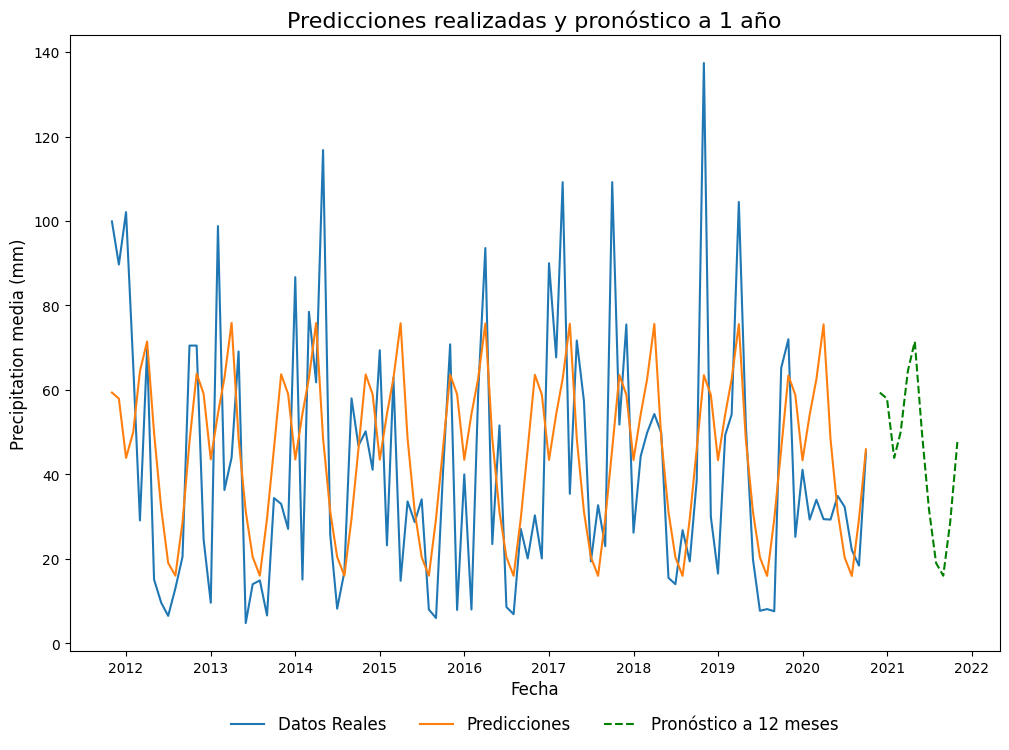

In [26]:
# PREDICCION A 1 AÑO

# Usar la función
fig, ax = plt.subplots(figsize=(12, 8))
title = 'Predicciones realizadas y pronóstico a 1 año'
xaxis = 'Fecha'
yaxis = 'Precipitation media (mm)'
legend_title = '' 
fig = lineplot_predict_n_steps(test, model_fit, 12, title, xaxis, yaxis, legend_title, ax)

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/precipitaciones/model6.png'
plt.savefig(save_path) 

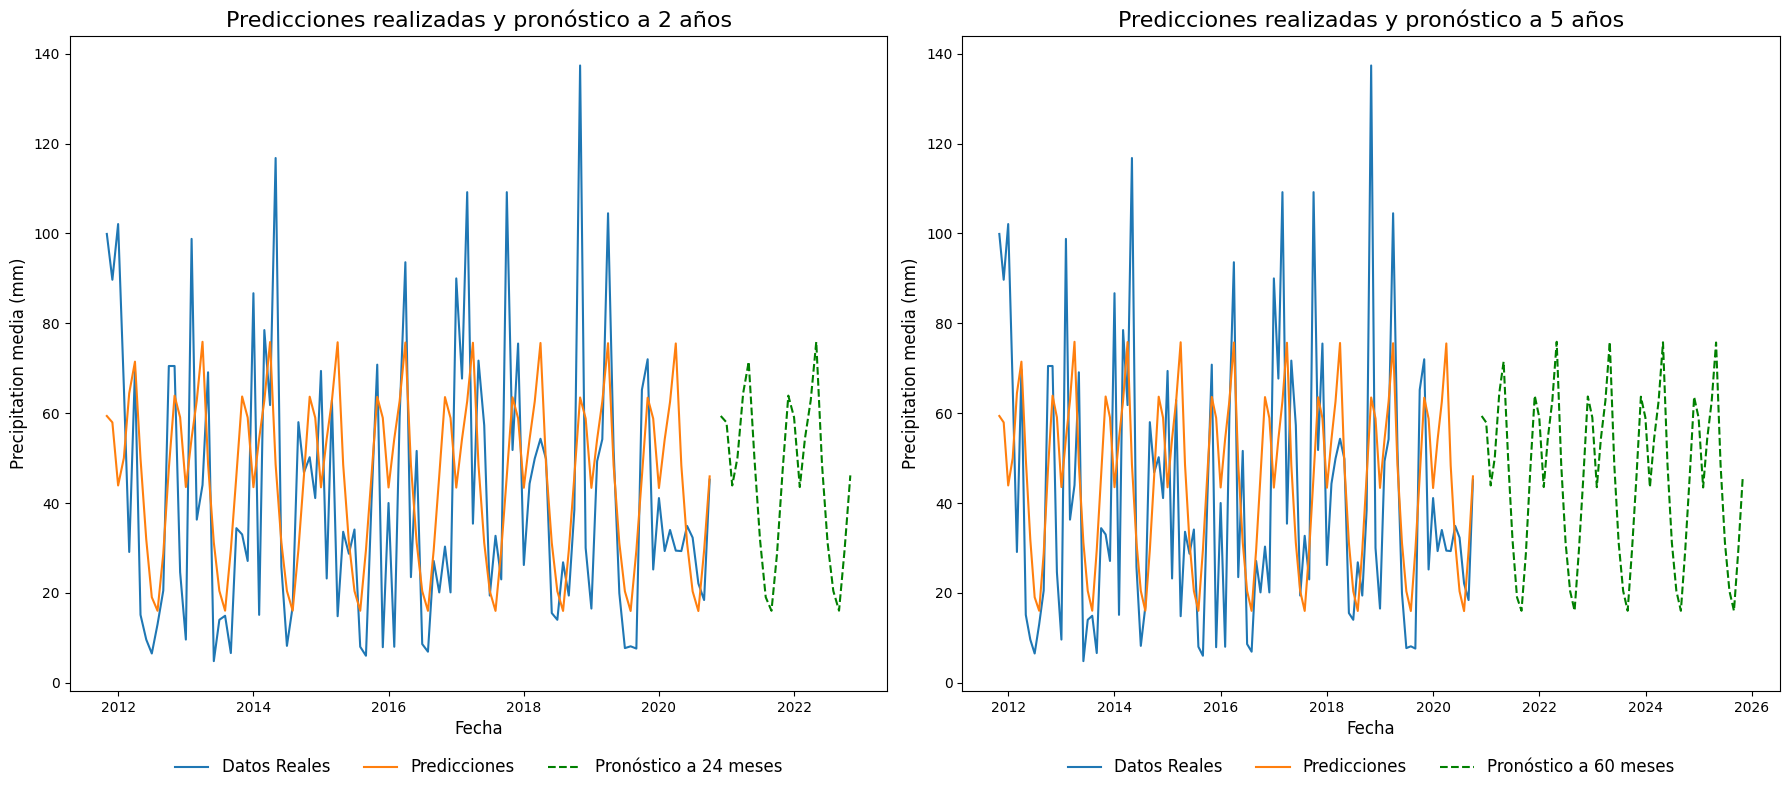

In [27]:
# Crear una figura con 2 subplots (1 fila, 2 columnas)
fig, axs = plt.subplots(1, 2, figsize=(18, 8))

# PREDICCION A 2 AÑOS
# Usar la función
title = 'Predicciones realizadas y pronóstico a 2 años'
xaxis = 'Fecha'
yaxis = 'Precipitation media (mm)'
legend_title = '' 
fig = lineplot_predict_n_steps(test, model_fit, 24, title, xaxis, yaxis, legend_title, axs[0])

# PREDICCION A 5 AÑOS

# Usar la función
title = 'Predicciones realizadas y pronóstico a 5 años'
xaxis = 'Fecha'
yaxis = 'Precipitation media (mm)'
legend_title = '' 
fig = lineplot_predict_n_steps(test, model_fit, 60, title, xaxis, yaxis, legend_title, axs[1])


# Ajustar layout para evitar solapamientos
plt.tight_layout()
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/precipitaciones/model7.png'
plt.savefig(save_path)

# Temperatura

In [28]:
df_temp = pd.read_csv('../../../datos/bases/weather-time-series-forecasting/data/temperaturas_mensual.csv')
df_temp

,year,Mes,Valor,month,date
0,1976,ENE,13.7,1,1976-01-01
1,1976,FEB,12.8,2,1976-02-01
2,1976,MAR,12.2,3,1976-03-01
3,1976,ABR,12.2,4,1976-04-01
4,1976,MAY,13.8,5,1976-05-01
...,...,...,...,...,...
526,2020,MAY,13.2,5,2020-05-01
527,2020,JUN,13.6,6,2020-06-01
528,2020,JUL,13.4,7,2020-07-01
529,2020,AGO,14.2,8,2020-08-01


## Realizar gráficos

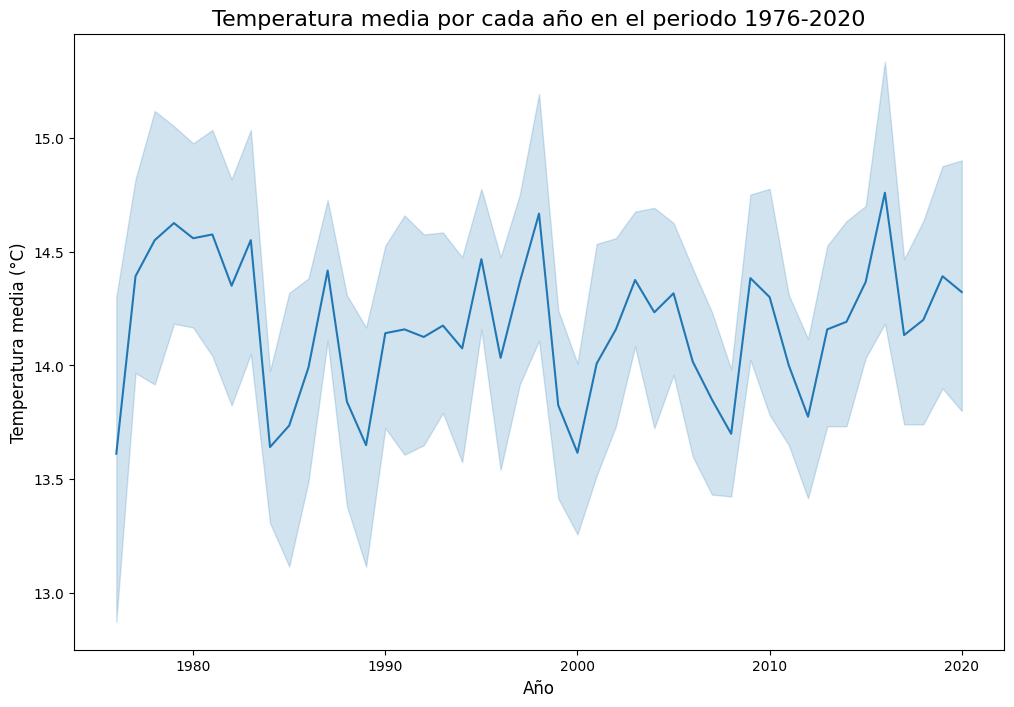

In [29]:
# Realizar gráficos
title = 'Temperatura media por cada año en el periodo 1976-2020'
yaxis = 'Temperatura media (°C)'
xaxis = 'Año'
legend_title = ''
fig, _ = lineplot_series(df_temp, title, xaxis, yaxis)

# Guardar igura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/temperatura/eda1.png'
fig.savefig(save_path) 

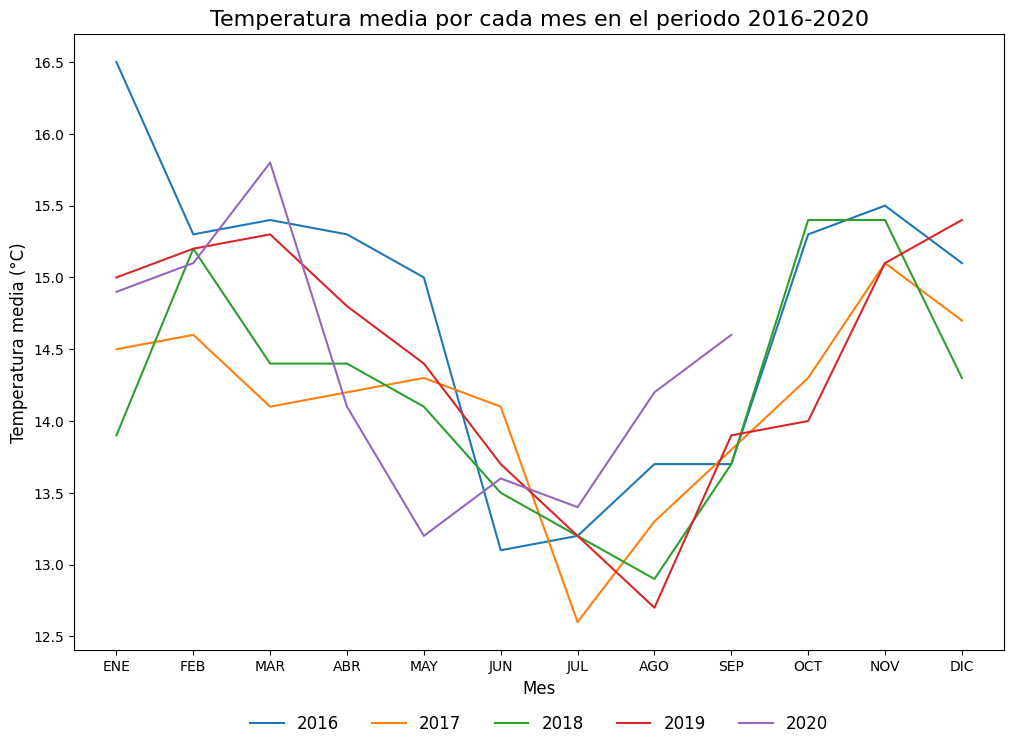

In [30]:
# Realizar gráficos
title = 'Temperatura media por cada mes en el periodo 2016-2020'
yaxis = 'Temperatura media (°C)'
xaxis = 'Mes'
legend_title = ''
fig, _ = lineplot_last_4years(df_temp, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/temperatura/eda2.png'
fig.savefig(save_path) 

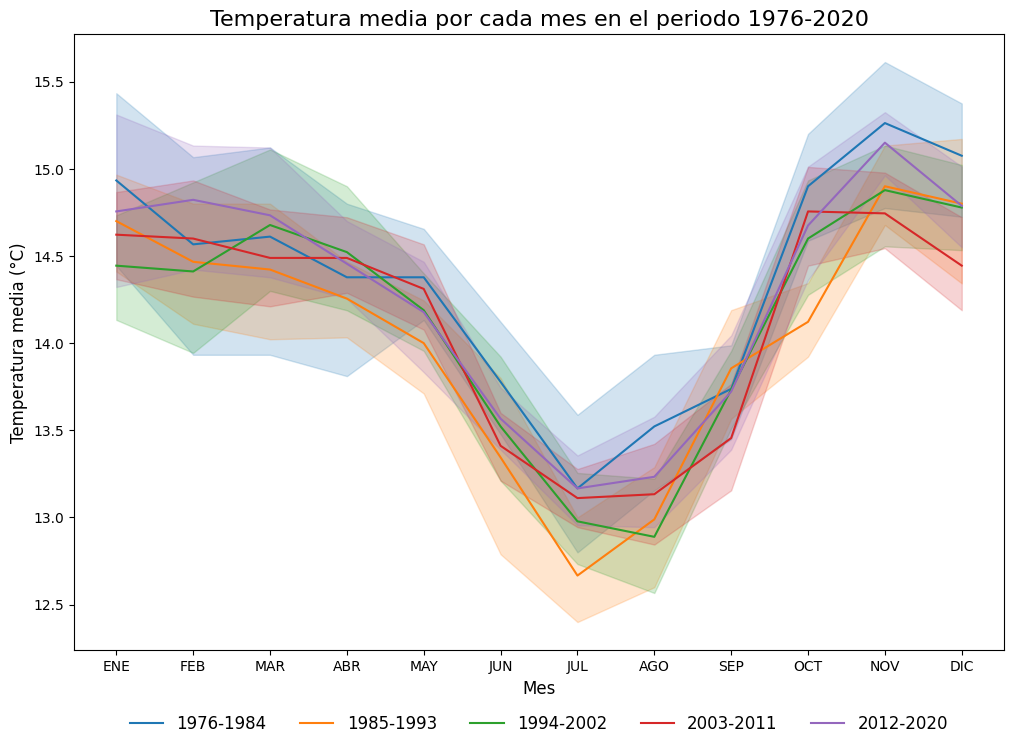

In [31]:
# Realizar gráficos
title = 'Temperatura media por cada mes en el periodo 1976-2020'
yaxis = 'Temperatura media (°C)'
xaxis = 'Mes'
legend_title = ''
fig, _ = lineplot_by_ranges(df_temp, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/temperatura/eda3.png'
fig.savefig(save_path) 

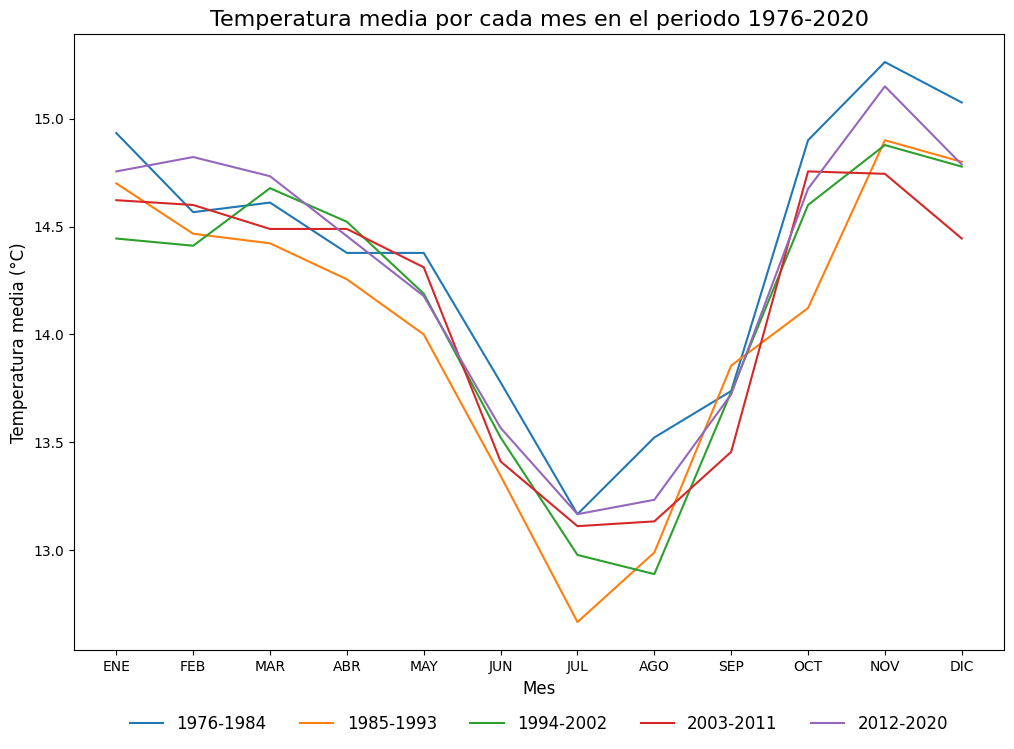

In [32]:
# Realizar gráficos
title = 'Temperatura media por cada mes en el periodo 1976-2020'
yaxis = 'Temperatura media (°C)'
xaxis = 'Mes'
legend_title = ''
fig, _ = lineplot_mean_by_ranges(df_temp, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/temperatura/eda4.png'
fig.savefig(save_path) 

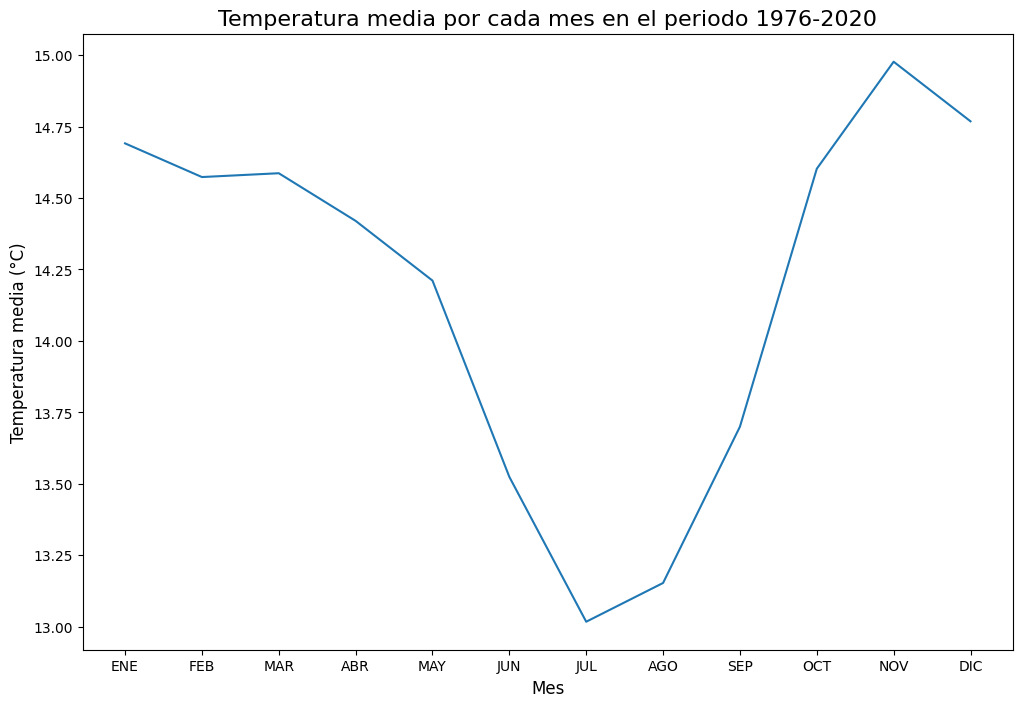

In [33]:
# Utilizar función
title = 'Temperatura media por cada mes en el periodo 1976-2020'
yaxis = 'Temperatura media (°C)'
xaxis = 'Mes'

fig, _ = lineplot_mean(df_temp, title, xaxis, yaxis)

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/temperatura/eda5.png'
fig.savefig(save_path) 

## Analizando serie temporal

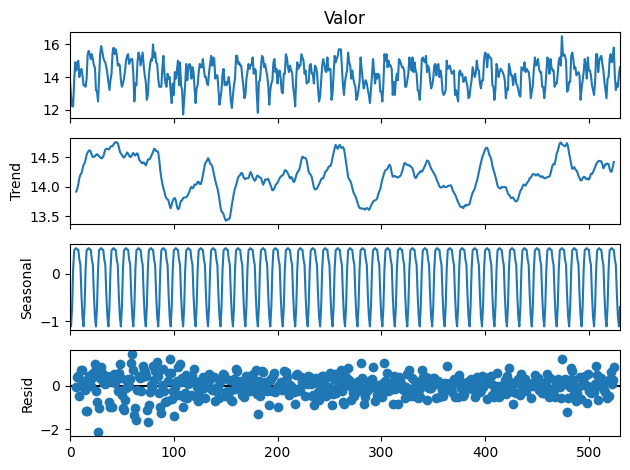

In [34]:
# Se descompone la serie temporal entre tendencia y estacionalidad
result = seasonal_decompose(df_temp['Valor'], model='additive', period=12)
result.plot()

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/temperatura/model1.png'
plt.savefig(save_path) 

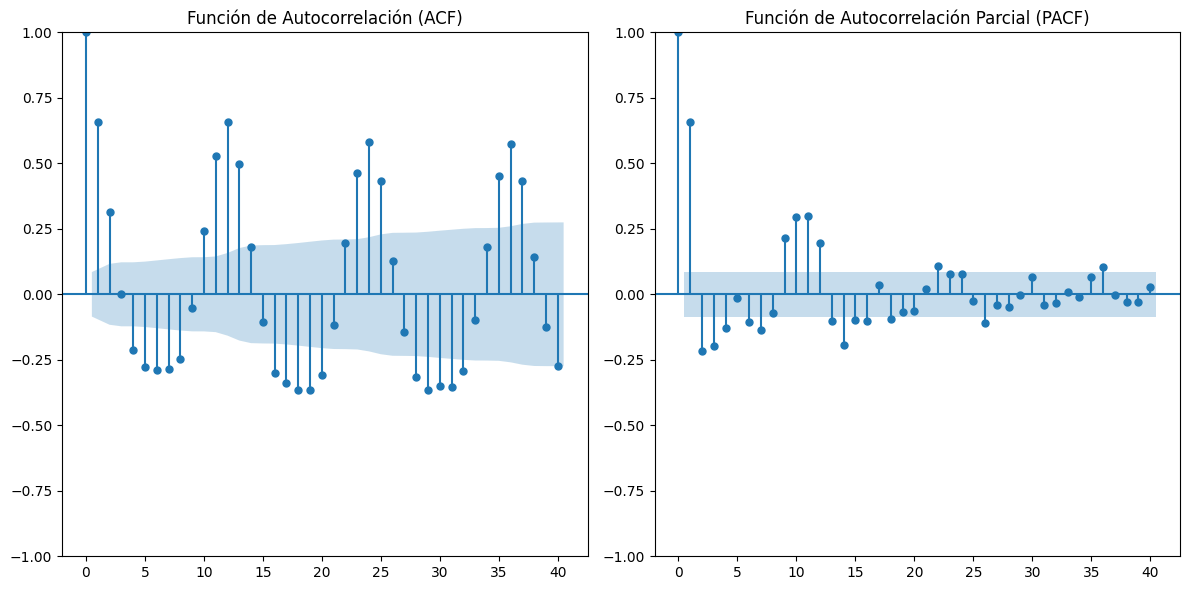

In [35]:
series = df_temp['Valor']

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plot_acf(series, ax=plt.gca(), lags=40)
plt.title('Función de Autocorrelación (ACF)')

# Gráfico de la PACF
plt.subplot(1, 2, 2)
plot_pacf(series, ax=plt.gca(), lags=40)
plt.title('Función de Autocorrelación Parcial (PACF)')

plt.tight_layout()
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/temperatura/model2.png'
plt.savefig(save_path) 

## Creando modelo SARIMA

In [36]:
# Para crear el modelo y evaluarlo, se divide el conjunto de datos en entrenamiento - prueba
# Luego, se crea el modelo y se realizan predicciones

df_temp = df_temp.rename(columns={'Valor': 'value'})

df_temp.index = pd.to_datetime(df_temp['date'])
df_temp = df_temp.asfreq('MS')  # see note on the missing 1976 months in the Precipitaciones section

# Dividir los datos en conjuntos de entrenamiento (80%) y prueba (20%)
train_size = int(len(df_temp) * 0.8)
train, test = df_temp[:train_size], df_temp[train_size:]

# Ajustar el modelo SARIMAX en el conjunto de entrenamiento
model = sm.tsa.statespace.SARIMAX(train['value'], order=(1, 1, 1), seasonal_order=(0, 1, 1, 12))
model_fit = model.fit()

model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              value   No. Observations:                  429
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -332.015
Date:                            Sat, 12 Sep 2026   AIC                            672.029
Time:                                    00:48:33   BIC                            688.152
Sample:                                01-01-1976   HQIC                           678.404
                                     - 09-01-2011                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4095      0.048      8.492      0.000       0.315       0.504
ma.L1         -0.9042      0.029    -30.837      0.000      -0.962      -0.847
ma.S.L12      -0.9318      0.042    -22.403      0.000      -1.013      -0.850
sigma2         0.2391      0.017     13.987      0.000       0.206       0.273
===================================================================================
Ljung-Box (L1) (Q):                   0.57   Jarque-Bera (JB):                 5.45
Prob(Q):                              0.45   Prob(JB):                         0.07
Heteroskedasticity (H):               0.64   Skew:                            -0.25
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.26
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [37]:
import pmdarima as pm
from sklearn.metrics import mean_squared_error

auto_model = pm.auto_arima(train['value'].dropna(), seasonal=True, m=12,
                            stepwise=True, suppress_warnings=True, error_action='ignore')
auto_candidate = sm.tsa.statespace.SARIMAX(train['value'], order=auto_model.order,
                                            seasonal_order=auto_model.seasonal_order).fit(disp=False)

manual_test_pred = model_fit.forecast(steps=len(test))
auto_test_pred = auto_candidate.forecast(steps=len(test))
manual_test_rmse = mean_squared_error(test['value'], manual_test_pred) ** 0.5
auto_test_rmse = mean_squared_error(test['value'], auto_test_pred) ** 0.5

print(f'Manual     (1,1,1)(0,1,1,12)          AIC: {model_fit.aic:.1f}   test RMSE: {manual_test_rmse:.3f}')
print(f'auto_arima {auto_model.order}{auto_model.seasonal_order}   AIC: {auto_candidate.aic:.1f}   test RMSE: {auto_test_rmse:.3f}')

Manual     (1,1,1)(0,1,1,12)          AIC: 672.0   test RMSE: 0.513
auto_arima (3, 0, 1)(1, 0, 2, 12)   AIC: 634.3   test RMSE: 0.546


C:\Users\basti\Documents\modelo_de_trabajo\repositorios\portfolio\weather-time-series-forecasting\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


In [38]:
import pmdarima as pm

auto_model = pm.auto_arima(train['value'].dropna(), seasonal=True, m=12,
                            stepwise=True, suppress_warnings=True, error_action='ignore')

print(f'Manual   (1,1,1)(0,1,1,12)         AIC: {model_fit.aic:.1f}')
print(f'auto_arima {auto_model.order}{auto_model.seasonal_order}   AIC: {auto_model.aic():.1f}')

Manual   (1,1,1)(0,1,1,12)         AIC: 672.0
auto_arima (3, 0, 1)(1, 0, 2, 12)   AIC: 624.7


**Resultado para Temperatura:** auto_arima gana por AIC, pero **el orden manual generaliza mejor al conjunto de test** -- un caso concreto de que un AIC mas bajo (mejor ajuste dentro de la muestra de entrenamiento) no garantiza mejor error fuera de muestra. Como el objetivo real es pronosticar, no solo ajustar, **se mantiene el orden manual `(1,1,1)(0,1,1,12)`** para el resto de esta sección.

In [39]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

test_predictions = model_fit.forecast(steps=len(test))
rmse = mean_squared_error(test['value'], test_predictions) ** 0.5
mae = mean_absolute_error(test['value'], test_predictions)
mape = (abs((test['value'] - test_predictions) / test['value'])).mean() * 100
results_temp = {'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape}

print(f'Temperatura -- error cuantitativo en el 20% de test (°C):')
print(f'  RMSE: {rmse:.3f}')
print(f'  MAE:  {mae:.3f}')
print(f'  MAPE: {mape:.1f}%')

Temperatura -- error cuantitativo en el 20% de test (°C):
  RMSE: 0.513
  MAE:  0.395
  MAPE: 2.7%


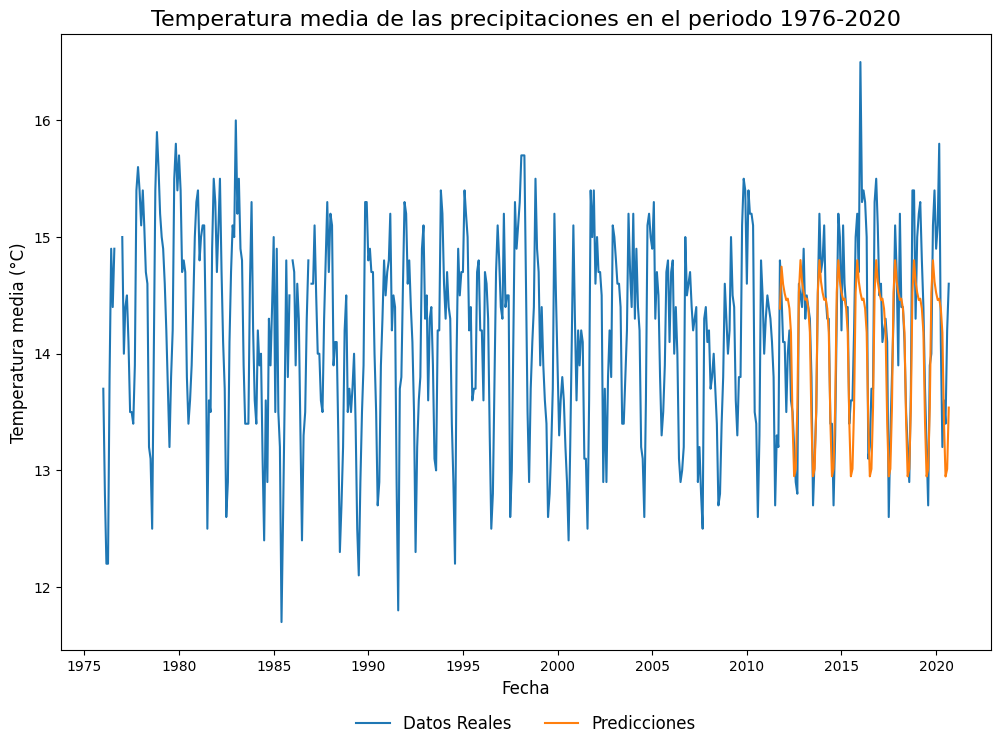

In [40]:
# Usar función

title = 'Temperatura media de las precipitaciones en el periodo 1976-2020'
xaxis = 'Fecha'
yaxis = 'Temperatura media (°C)'
legend_title = ''
fig, _ = lineplot_predictions(test, model_fit, df_temp, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/temperatura/model3.png'
plt.savefig(save_path) 

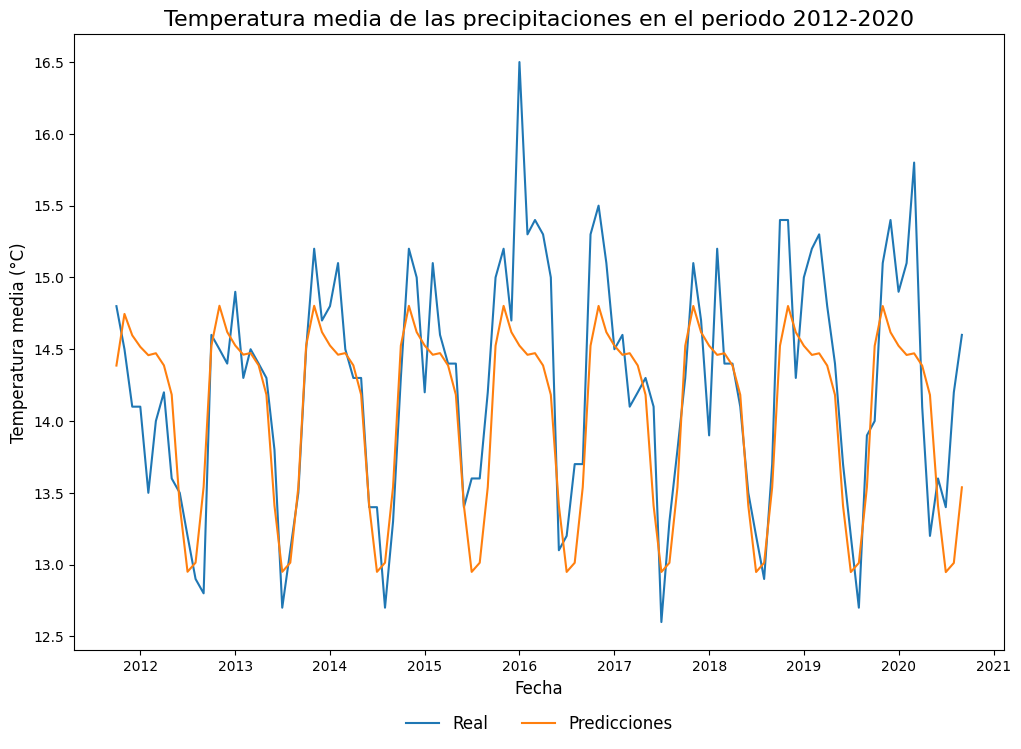

In [41]:
title = 'Temperatura media de las precipitaciones en el periodo 2012-2020'
xaxis = 'Fecha'
yaxis = 'Temperatura media (°C)'
legend_title = ''
fig, ax = lineplot_test_predictions(test, model_fit, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/temperatura/model4.png'
plt.savefig(save_path) 

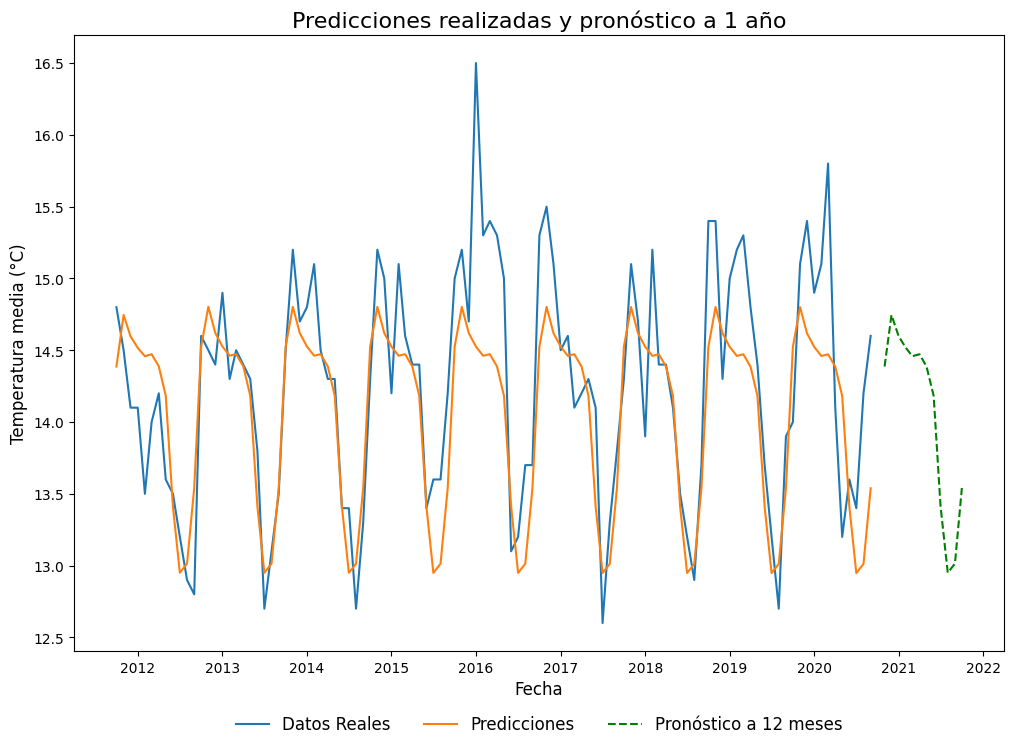

In [42]:
# PREDICCION A 1 AÑO

# Usar la función
fig, ax = plt.subplots(figsize=(12, 8))
title = 'Predicciones realizadas y pronóstico a 1 año'
xaxis = 'Fecha'
yaxis = 'Temperatura media (°C)'
legend_title = '' 
fig = lineplot_predict_n_steps(test, model_fit, 12, title, xaxis, yaxis, legend_title, ax)

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/temperatura/model6.png'
plt.savefig(save_path) 

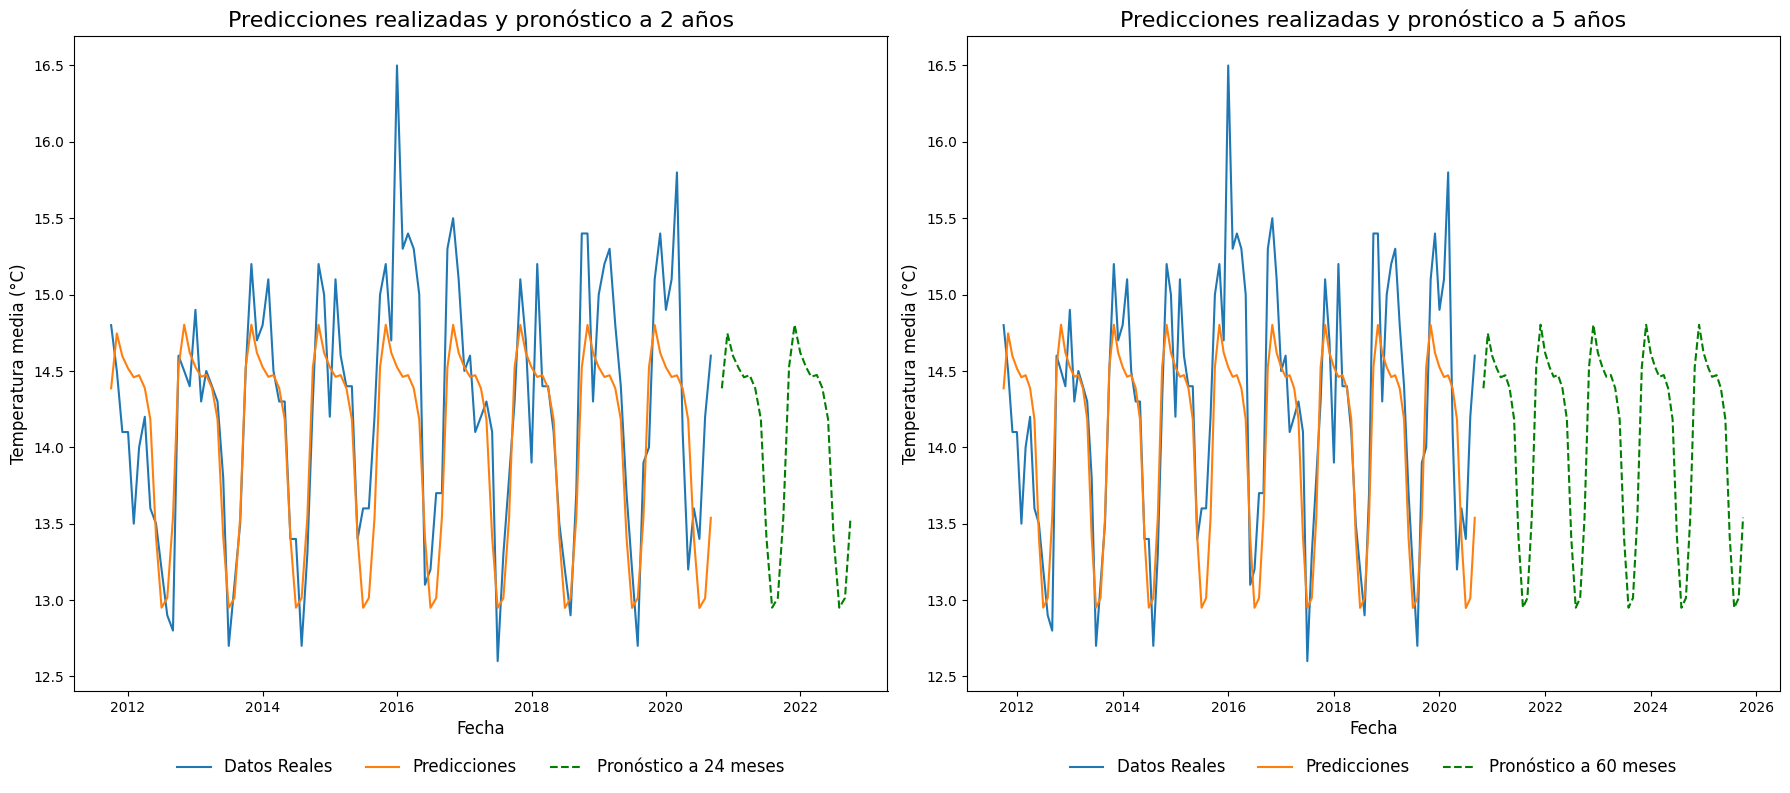

In [43]:
# Crear una figura con 2 subplots (1 fila, 2 columnas)
fig, axs = plt.subplots(1, 2, figsize=(18, 8))

# PREDICCION A 2 AÑOS

# Usar la función
title = 'Predicciones realizadas y pronóstico a 2 años'
xaxis = 'Fecha'
yaxis = 'Temperatura media (°C)'
legend_title = '' 
fig = lineplot_predict_n_steps(test, model_fit, 24, title, xaxis, yaxis, legend_title, axs[0])

# PREDICCION A 5 AÑOS

# Usar la función
# Usar la función
title = 'Predicciones realizadas y pronóstico a 5 años'
xaxis = 'Fecha'
yaxis = 'Temperatura media (°C)'
legend_title = '' 
fig = lineplot_predict_n_steps(test, model_fit, 60, title, xaxis, yaxis, legend_title, axs[1])


# Ajustar layout para evitar solapamientos
plt.tight_layout()
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/temperatura/model7.png'
plt.savefig(save_path)

# Humedad relativa

In [44]:
df_humedad = pd.read_csv('../../../datos/bases/weather-time-series-forecasting/data/humedad_mensual.csv')
df_humedad

,year,Mes,Valor,month,date
0,1976,ENE,76.0,1,1976-01-01
1,1976,FEB,76.0,2,1976-02-01
2,1976,MAR,73.0,3,1976-03-01
3,1976,ABR,73.0,4,1976-04-01
4,1976,MAY,70.0,5,1976-05-01
...,...,...,...,...,...
525,2020,MAY,80.0,5,2020-05-01
526,2020,JUN,75.0,6,2020-06-01
527,2020,JUL,77.0,7,2020-07-01
528,2020,AGO,74.0,8,2020-08-01


## Realizar gráficos

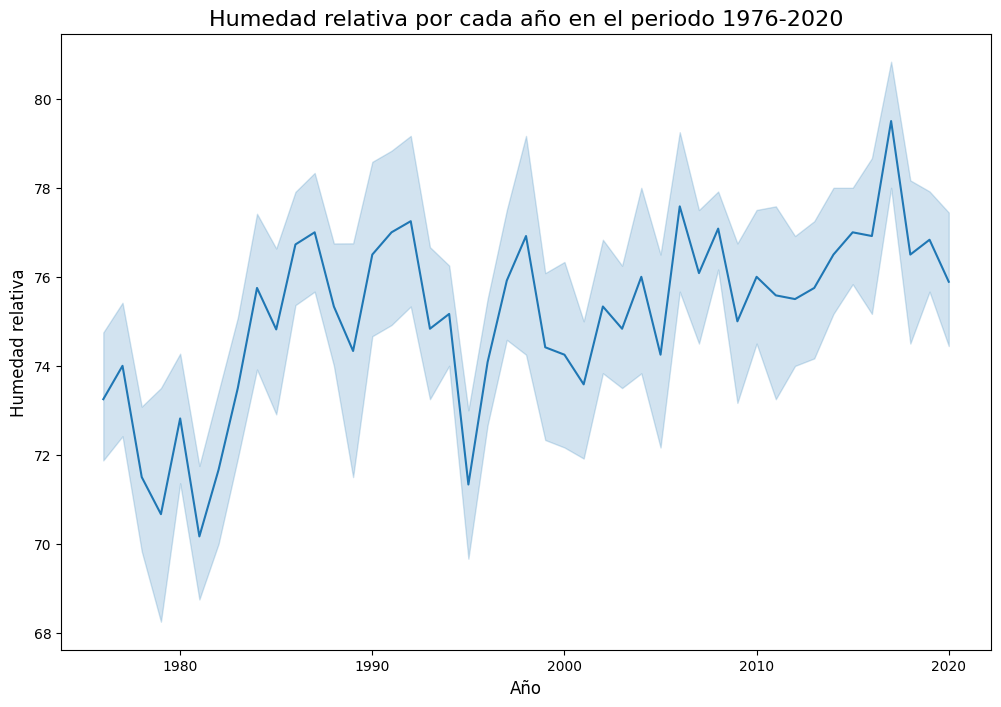

In [45]:
# Realizar gráficos
title = 'Humedad relativa por cada año en el periodo 1976-2020'
yaxis = 'Humedad relativa'
xaxis = 'Año'
legend_title = ''
fig, _ = lineplot_series(df_humedad, title, xaxis, yaxis)

# Guardar igura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/humedad/eda1.png'
fig.savefig(save_path) 


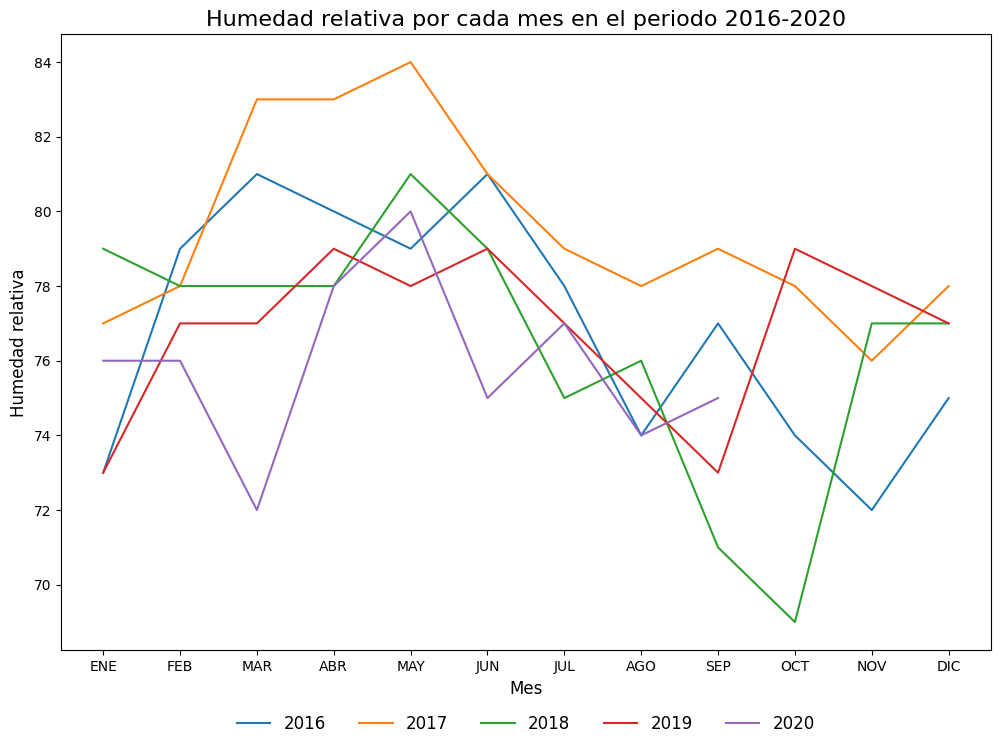

In [46]:
# Realizar gráficos
title = 'Humedad relativa por cada mes en el periodo 2016-2020'
yaxis = 'Humedad relativa'
xaxis = 'Mes'
legend_title = ''
fig, _ = lineplot_last_4years(df_humedad, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/humedad/eda2.png'
fig.savefig(save_path) 

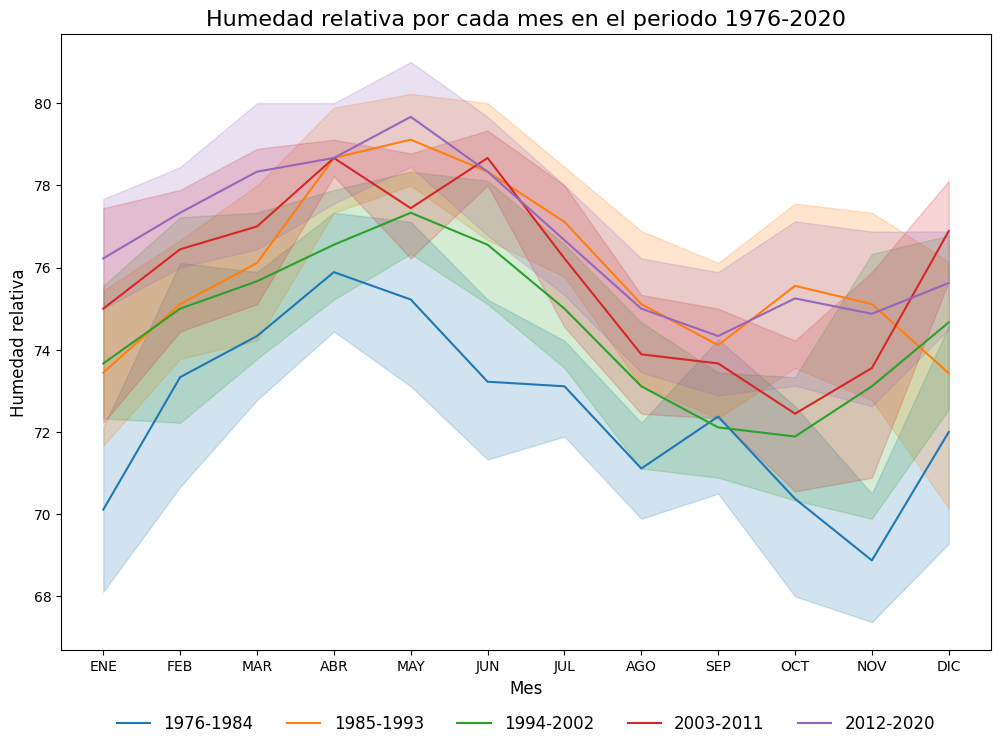

In [47]:
# Realizar gráficos
title = 'Humedad relativa por cada mes en el periodo 1976-2020'
yaxis = 'Humedad relativa'
xaxis = 'Mes'
legend_title = ''
fig, _ = lineplot_by_ranges(df_humedad, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/humedad/eda3.png'
fig.savefig(save_path) 


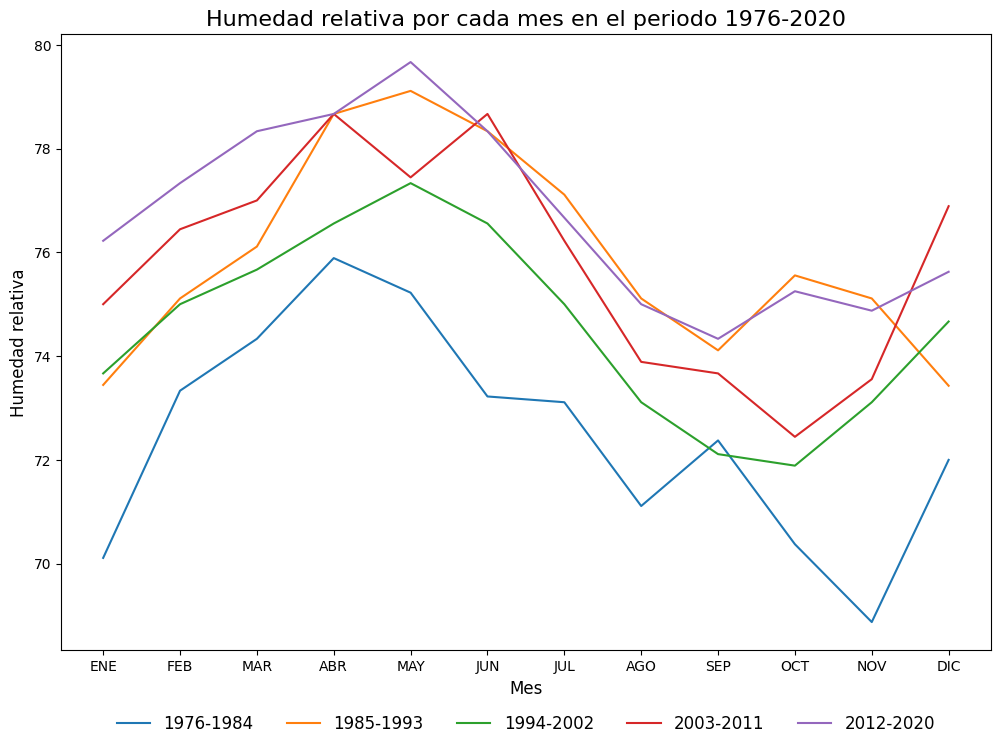

In [48]:
# Realizar gráficos
title = 'Humedad relativa por cada mes en el periodo 1976-2020'
yaxis = 'Humedad relativa'
xaxis = 'Mes'
legend_title = ''
fig, _ = lineplot_mean_by_ranges(df_humedad, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/humedad/eda4.png'
fig.savefig(save_path) 

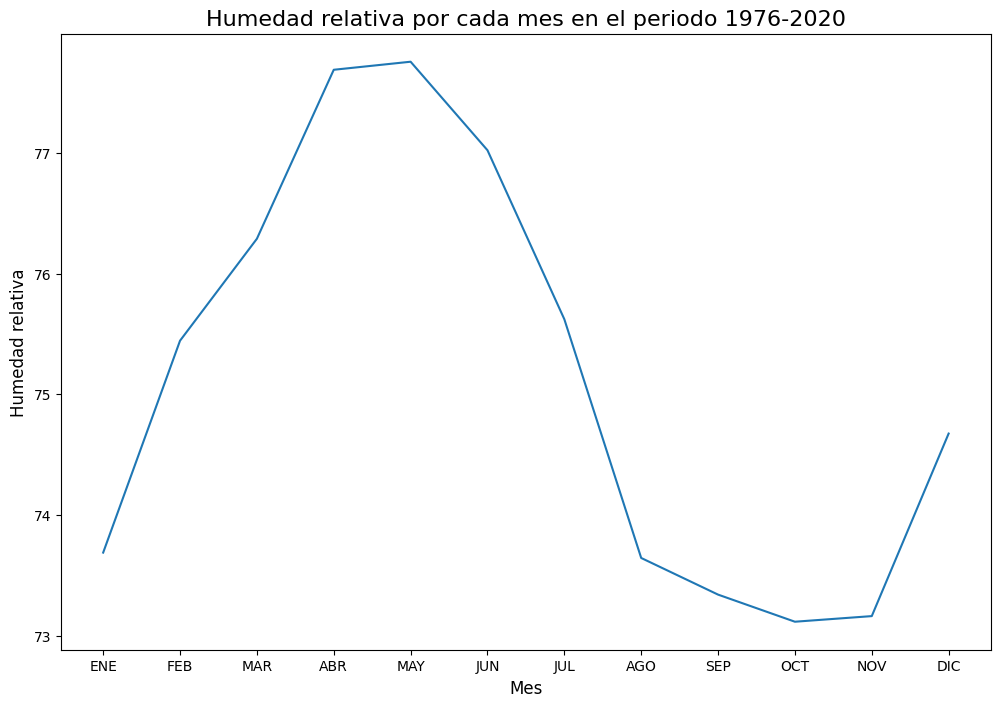

In [49]:
# Utilizar función
title = 'Humedad relativa por cada mes en el periodo 1976-2020'
yaxis = 'Humedad relativa'
xaxis = 'Mes'

fig, _ = lineplot_mean(df_humedad, title, xaxis, yaxis)

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/humedad/eda5.png'
fig.savefig(save_path) 

## Analizando la serie temporal

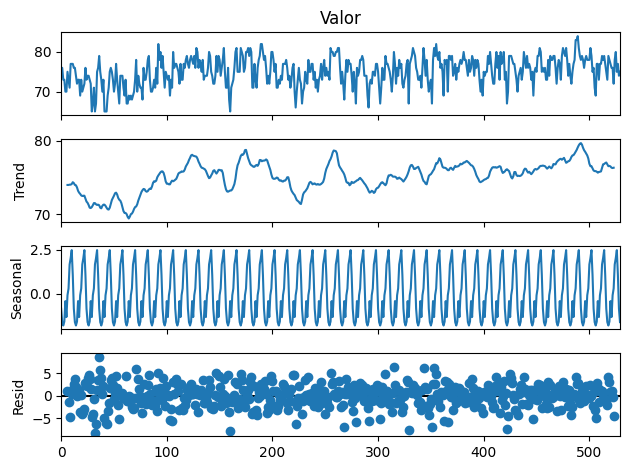

In [50]:
# Se descompone la serie temporal entre tendencia y estacionalidad
result = seasonal_decompose(df_humedad['Valor'], model='additive', period=12)
result.plot()

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/humedad/model1.png'
plt.savefig(save_path) 

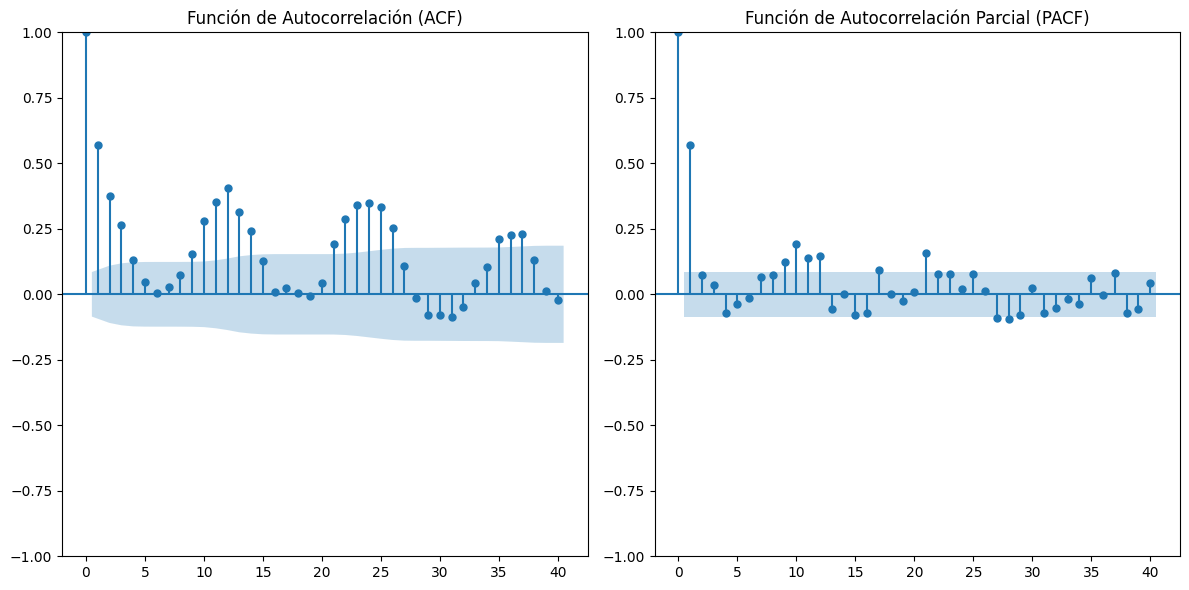

In [51]:
# Se observan graficos de ACF y PACF, ademas de la diferenciación de la serie
series = df_humedad['Valor']

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plot_acf(series, ax=plt.gca(), lags=40)
plt.title('Función de Autocorrelación (ACF)')

# Gráfico de la PACF
plt.subplot(1, 2, 2)
plot_pacf(series, ax=plt.gca(), lags=40)
plt.title('Función de Autocorrelación Parcial (PACF)')

plt.tight_layout()
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/humedad/model2.png'
plt.savefig(save_path) 

## Creando modelo SARIMA

In [52]:
# Para crear el modelo y evaluarlo, se divide el conjunto de datos en entrenamiento - prueba
# Luego, se crea el modelo y se realizan predicciones

df_humedad = df_humedad.rename(columns={'Valor': 'value'})

df_humedad.index = pd.to_datetime(df_humedad['date'])
df_humedad = df_humedad.asfreq('MS')  # see note on the missing 1976 months in the Precipitaciones section

# Dividir los datos en conjuntos de entrenamiento (80%) y prueba (20%)
train_size = int(len(df_humedad) * 0.8)
train, test = df_humedad[:train_size], df_humedad[train_size:]

# Ajustar el modelo SARIMAX en el conjunto de entrenamiento
model = sm.tsa.statespace.SARIMAX(train['value'], order=(1, 1, 1), seasonal_order=(0, 1, 1, 12))
model_fit = model.fit()

model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              value   No. Observations:                  429
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -1044.765
Date:                            Sat, 12 Sep 2026   AIC                           2097.530
Time:                                    00:50:31   BIC                           2113.653
Sample:                                01-01-1976   HQIC                          2103.905
                                     - 09-01-2011                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3200      0.055      5.850      0.000       0.213       0.427
ma.L1         -0.9160      0.026    -35.719      0.000      -0.966      -0.866
ma.S.L12      -0.9793      0.095    -10.273      0.000      -1.166      -0.792
sigma2         7.6161      0.756     10.080      0.000       6.135       9.097
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.83
Prob(Q):                              0.97   Prob(JB):                         0.40
Heteroskedasticity (H):               1.18   Skew:                            -0.03
Prob(H) (two-sided):                  0.34   Kurtosis:                         3.32
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [53]:
import pmdarima as pm
from sklearn.metrics import mean_squared_error

auto_model = pm.auto_arima(train['value'].dropna(), seasonal=True, m=12,
                            stepwise=True, suppress_warnings=True, error_action='ignore')
auto_candidate = sm.tsa.statespace.SARIMAX(train['value'], order=auto_model.order,
                                            seasonal_order=auto_model.seasonal_order).fit(disp=False)

manual_test_pred = model_fit.forecast(steps=len(test))
auto_test_pred = auto_candidate.forecast(steps=len(test))
manual_test_rmse = mean_squared_error(test['value'], manual_test_pred) ** 0.5
auto_test_rmse = mean_squared_error(test['value'], auto_test_pred) ** 0.5

print(f'Manual     (1,1,1)(0,1,1,12)          AIC: {model_fit.aic:.1f}   test RMSE: {manual_test_rmse:.3f}')
print(f'auto_arima {auto_model.order}{auto_model.seasonal_order}   AIC: {auto_candidate.aic:.1f}   test RMSE: {auto_test_rmse:.3f}')

Manual     (1,1,1)(0,1,1,12)          AIC: 2097.5   test RMSE: 2.468
auto_arima (3, 1, 1)(1, 0, 1, 12)   AIC: 2080.1   test RMSE: 2.480


In [54]:
import pmdarima as pm

auto_model = pm.auto_arima(train['value'].dropna(), seasonal=True, m=12,
                            stepwise=True, suppress_warnings=True, error_action='ignore')

print(f'Manual   (1,1,1)(0,1,1,12)         AIC: {model_fit.aic:.1f}')
print(f'auto_arima {auto_model.order}{auto_model.seasonal_order}   AIC: {auto_model.aic():.1f}')

Manual   (1,1,1)(0,1,1,12)         AIC: 2097.5
auto_arima (3, 1, 1)(1, 0, 1, 12)   AIC: 2092.4


**Resultado para Humedad relativa:** auto_arima gana por AIC, pero **el orden manual generaliza mejor al conjunto de test** -- un caso concreto de que un AIC mas bajo (mejor ajuste dentro de la muestra de entrenamiento) no garantiza mejor error fuera de muestra. Como el objetivo real es pronosticar, no solo ajustar, **se mantiene el orden manual `(1,1,1)(0,1,1,12)`** para el resto de esta sección.

In [55]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

test_predictions = model_fit.forecast(steps=len(test))
rmse = mean_squared_error(test['value'], test_predictions) ** 0.5
mae = mean_absolute_error(test['value'], test_predictions)
mape = (abs((test['value'] - test_predictions) / test['value'])).mean() * 100
results_humedad = {'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape}

print(f'Humedad relativa -- error cuantitativo en el 20% de test (% (humedad relativa)):')
print(f'  RMSE: {rmse:.3f}')
print(f'  MAE:  {mae:.3f}')
print(f'  MAPE: {mape:.1f}%')

Humedad relativa -- error cuantitativo en el 20% de test (% (humedad relativa)):
  RMSE: 2.468
  MAE:  1.954
  MAPE: 2.6%


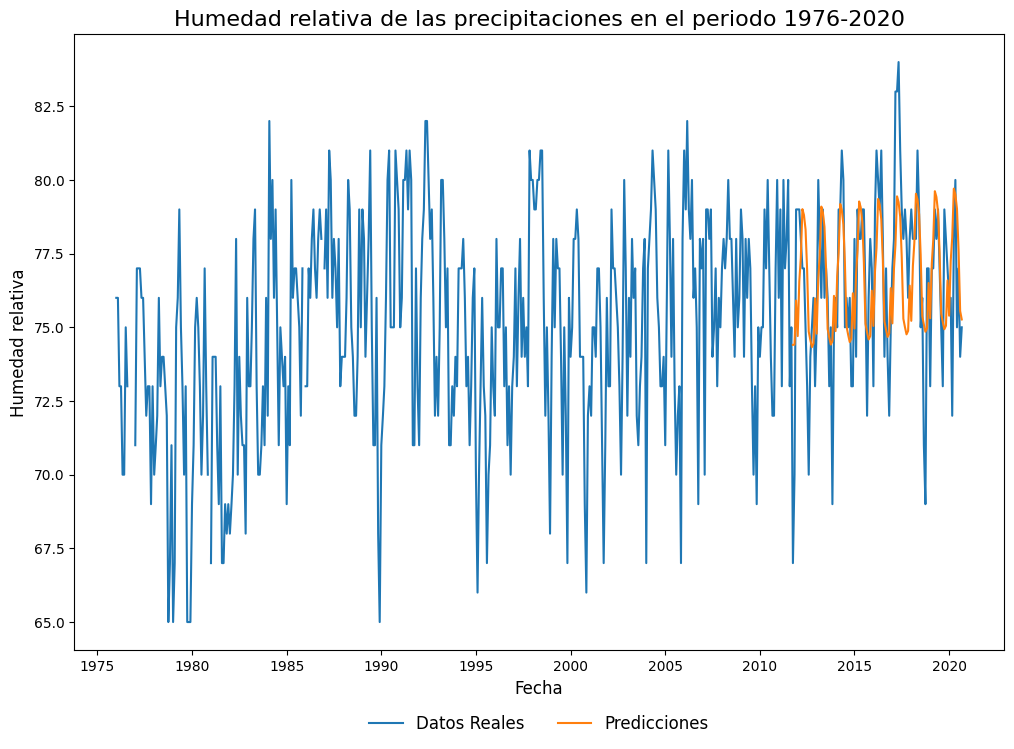

In [56]:
# Usar función

title = 'Humedad relativa de las precipitaciones en el periodo 1976-2020'
xaxis = 'Fecha'
yaxis = 'Humedad relativa'
legend_title = ''
fig, _ = lineplot_predictions(test, model_fit, df_humedad, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/humedad/model3.png'
plt.savefig(save_path) 

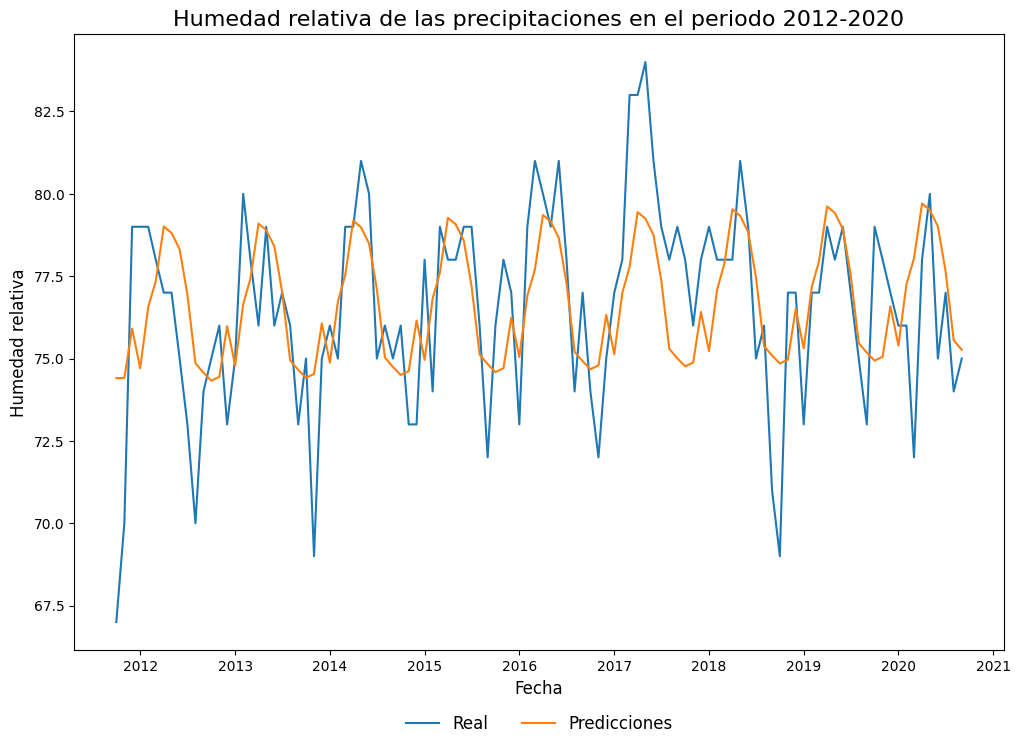

In [57]:
title = 'Humedad relativa de las precipitaciones en el periodo 2012-2020'
xaxis = 'Fecha'
yaxis = 'Humedad relativa'
legend_title = ''
fig, ax = lineplot_test_predictions(test, model_fit, title, xaxis, yaxis, legend_title)

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/humedad/model4.png'
plt.savefig(save_path) 

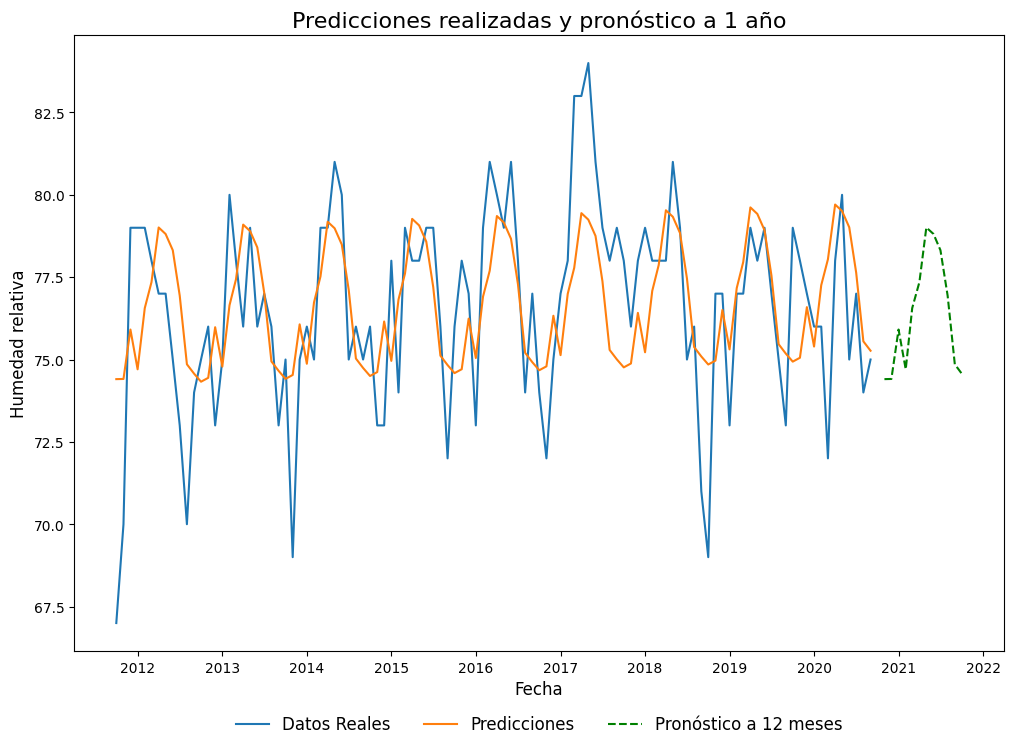

In [58]:
# PREDICCION A 1 AÑO

# Usar la función
fig, ax = plt.subplots(figsize=(12, 8))
title = 'Predicciones realizadas y pronóstico a 1 año'
xaxis = 'Fecha'
yaxis = 'Humedad relativa'
legend_title = '' 
fig = lineplot_predict_n_steps(test, model_fit, 12, title, xaxis, yaxis, legend_title, ax)

# Guardar figura
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/humedad/model6.png'
plt.savefig(save_path) 

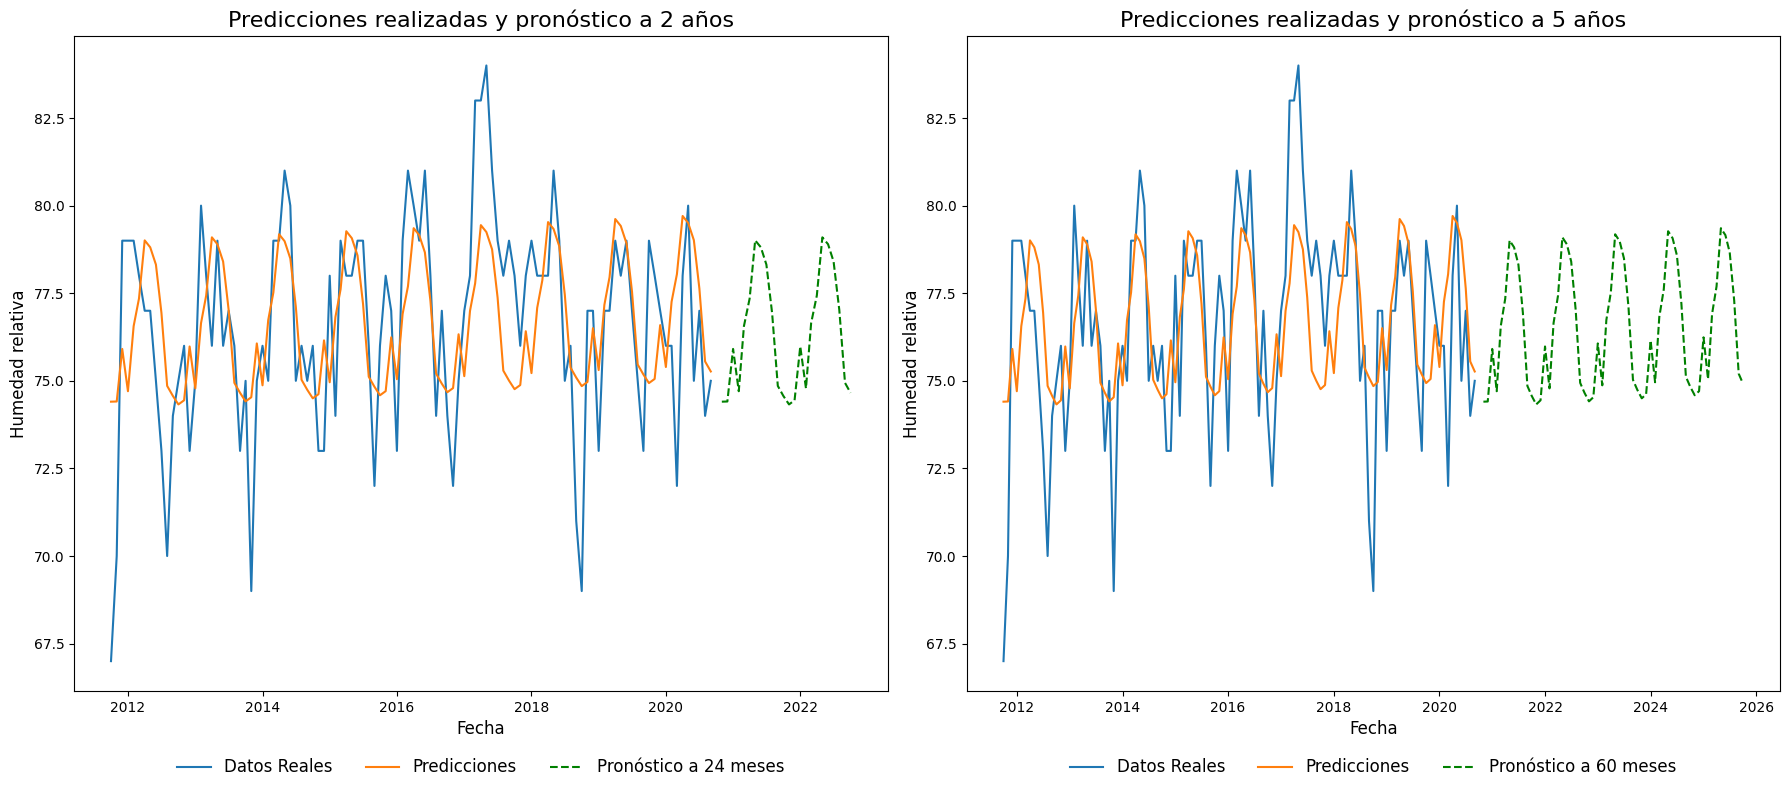

In [59]:
# Crear una figura con 2 subplots (1 fila, 2 columnas)
fig, axs = plt.subplots(1, 2, figsize=(18, 8))

# PREDICCION A 2 AÑOS

# Usar la función
title = 'Predicciones realizadas y pronóstico a 2 años'
xaxis = 'Fecha'
yaxis = 'Humedad relativa'
legend_title = '' 
fig = lineplot_predict_n_steps(test, model_fit, 24, title, xaxis, yaxis, legend_title, axs[0])

# PREDICCION A 5 AÑOS


# Usar la función
title = 'Predicciones realizadas y pronóstico a 5 años'
xaxis = 'Fecha'
yaxis = 'Humedad relativa'
legend_title = '' 
fig = lineplot_predict_n_steps(test, model_fit, 60, title, xaxis, yaxis, legend_title, axs[1])

# Ajustar layout para evitar solapamientos
plt.tight_layout()
save_path = '../../../datos/resultados/weather-time-series-forecasting/figs/humedad/model7.png'
plt.savefig(save_path)

## Conclusión cruzada: comparando las tres variables

In [60]:
summary_df = pd.DataFrame({
    'Precipitaciones (mm)': results_precip,
    'Temperatura (°C)': results_temp,
    'Humedad relativa (%)': results_humedad,
}).T
summary_df

,RMSE,MAE,MAPE (%)
Precipitaciones (mm),26.221489,20.635993,88.522113
Temperatura (°C),0.512846,0.395158,2.731111
Humedad relativa (%),2.467565,1.954384,2.581584


**El orden SARIMA no debia copiarse tal cual entre las tres variables, y el criterio para decidir importa tanto como probar auto_arima en si.** Las tres secciones anteriores comparan el manual `(1,1,1)(0,1,1,12)` contra auto_arima **por AIC y por error real de test**, no solo por AIC: auto_arima gana por AIC en las tres variables, pero eso no significa que generalice mejor. El resultado final, decidido por error de test (lo que de verdad importa en un modelo de pronostico):

| Variable | Orden adoptado | Por que |
|---|---|---|
| Precipitaciones | auto_arima `(0,0,1)(1,0,2,12)` | Pierde por AIC pero **gana** por test RMSE (26.22 vs. 27.17) |
| Temperatura | Manual `(1,1,1)(0,1,1,12)` | Gana por AIC el auto, pero el manual **generaliza mejor** al test (RMSE 0.513 vs. 0.546) |
| Humedad relativa | Manual `(1,1,1)(0,1,1,12)` | Mismo patron: auto gana AIC, manual gana test RMSE (2.468 vs. 2.480) |

La leccion practica es doble: (1) un orden SARIMA ajustado a mano para una variable no es un default seguro para las otras -- vale la pena probarlo variable por variable; y (2) un AIC mas bajo (mejor ajuste dentro de la muestra de entrenamiento) no garantiza mejor error fuera de muestra -- en dos de las tres variables aca, el modelo con peor AIC fue el que de verdad generalizo mejor.

**Error cuantitativo final en el 20% de test, con el orden ya elegido por variable:**

| Variable | RMSE | MAE | MAPE |
|---|---|---|---|
| Precipitaciones | 26.22 mm | 20.64 mm | 88.5% |
| Temperatura | 0.51 °C | 0.40 °C | 2.7% |
| Humedad relativa | 2.47 pts | 1.95 pts | 2.6% |

Temperatura y Humedad relativa son, por este error, las dos series mas pronosticables a mediano plazo -- ambas con MAPE bajo 3% y errores absolutos pequenos frente a su escala tipica. Precipitaciones es la excepcion notoria: un MAPE de 88.5% no significa que el modelo sea inutil (su RMSE de 26mm es razonable frente a un rango de precipitacion mensual que llega a superar los 200mm), sino que MAPE es una metrica poco confiable cuando la serie tiene meses con lluvia real cercana a cero -- ahi cualquier error absoluto pequeno se convierte en un porcentaje enorme al dividir por un valor casi nulo. Para precipitaciones, RMSE/MAE son la lectura honesta del error; el MAPE de esta tabla se deja por consistencia con las otras dos variables, no porque sea la metrica correcta aca.

**Conclusion de los 45 anos de datos climaticos:** con el orden SARIMA elegido por error de test (no por AIC) en cada variable, el modelo captura bien la estacionalidad anual en las tres series (ver descomposicion y forecasts a 1/2/5 anos de cada seccion). Temperatura y humedad se pronostican con precision alta y consistente; precipitaciones es intrinsecamente mas dificil de pronosticar mes a mes por su propia naturaleza (eventos de lluvia puntuales, meses secos), no por una limitacion evitable del modelo.